In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import scipy.stats as st
import numpy as np
from pathlib import Path
from scipy.interpolate import make_smoothing_spline
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

from statsmodels.stats.multitest import multipletests

from collections import defaultdict, OrderedDict
from pycirclize import Circos
# sns.set_theme(font_scale = 1, style = 'ticks')



# Load data

In [2]:
repo_folder = Path('../../..')
data_folder  = repo_folder / 'data'/ 'this_project' / '6_transporterKO'
metabolomics_folder = data_folder / 'D_big_screen'
figure_folder = repo_folder / 'figures'/'3_big_screen'


In [3]:
normalization = 'TIC'
median_fn = metabolomics_folder / f'G_median_z_scores_{normalization}_norm_keio.csv'
df_data = pd.read_csv(median_fn)
df_data.rename(columns={'Z-score median': 'Median Z-score'}, inplace=True)

ionMz_annotation_fn = metabolomics_folder / 'H_ionMz_annotation.csv'
df_ionMz = pd.read_csv(ionMz_annotation_fn)
df_ionMz.drop_duplicates(subset=['ionMz'], inplace=True)

sample_metadata_fn = metabolomics_folder / 'I_sample_metadata_keio.csv'
df_sample_metadata = pd.read_csv(sample_metadata_fn)

auc_df = pd.read_csv(metabolomics_folder / 'J_auc_z_scores_keio.csv')

lam = 10
xval = 'AUC OD'
distance_fn = metabolomics_folder / f'K_timecurve_comparison_{normalization}_norm_lam_{lam}_{xval}.csv'
dis_df = pd.read_csv(distance_fn, index_col=0)


name_to_mz_fn = data_folder / 'Z_div/H_name_to_mz.csv'
name_to_mz_df = pd.read_csv(name_to_mz_fn)
name_to_mz_df['ionMz'] = name_to_mz_df.ionMz.str.split(';')
name_to_ionMz = {row['Name']: [float(x) for x in row['ionMz']] for _, row in name_to_mz_df.iterrows()}


In [4]:
df_mz = df_data.merge(df_ionMz, on='ionMz', how='left')
dis_mz = dis_df.merge(df_ionMz, on='ionMz', how='left')

In [5]:
df = df_mz.merge(df_sample_metadata, on=['Batch-Tube', 'Timepoint'], how='left')

In [6]:
df.sort_values(by=['Batch-Tube', 'ionMz', 'Hours'], inplace=True)

## Load OD data

In [7]:
od_fn = metabolomics_folder / 'B_od_data.csv'
od_df = pd.read_csv(od_fn, index_col=0)
od_df.sort_values(by = 'Strain', inplace = True)

# Drop slow strains

In [8]:
# Slow growing strains
drop_strains = ['dppB', 'tolC', 'ptsG',]
auc_df = auc_df[~auc_df.Strain.isin(drop_strains)]
dis_mz = dis_mz[~dis_mz.Strain.isin(drop_strains)]
df = df[~df.Strain.isin(drop_strains)]

In [9]:
dis_mz.shape

(15848, 19)

In [10]:
max_pval = 0.005
min_effect = 3
sel_idx = (dis_mz['Rel. distance'].abs() > min_effect)&(dis_mz['p-value rel'] < max_pval)
sel_df = dis_mz.loc[sel_idx].copy()

In [11]:
idx = sel_df.Strain == 'actP'
plot_data = sel_df.loc[idx].copy()
plot_data.sort_values(by='Rel. distance', ascending=False, inplace=True)

In [12]:
import plotly.graph_objects as go
fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=plot_data['Metabolite'],
        y=plot_data['Rel. distance'],
        marker_color='indianred',
        name='Effect size'
    )
)
fig.update_layout(
    xaxis_title="Metabolite",
    yaxis_title="Rel. distance",
    title_text=f"Significant effect for {'as'} (P < {max_pval}, |Effect| > {min_effect})",
)

# Positive effects

In [13]:
def plot_timecourse_difference(ax, df,batches, strains,ion_mz, xval='Hours', yval='Median Z-score', ystd='Z-score std'):
    data = df.loc[df.ionMz.isin(ionMz)&(df.Strain.isin(strains))&(df['Batch'].isin(batches))].copy()
    data.sort_values(by=['Strain', xval], inplace=True)

    for i, strain in enumerate(strains):
        strain_data = data.loc[data.Strain == strain].copy()
        is_duplicated = strain_data[xval].duplicated()
        if np.any(is_duplicated):
            strain_data.loc[is_duplicated, xval] += sorted([np.abs(x) for x in np.random.normal(0, 1e-2, size=is_duplicated.sum())])
        strain_data.sort_values(by = xval, inplace=True)
        x = strain_data[xval].values
        y = strain_data[yval].values
        y_std = strain_data[ystd].values
        spline = make_smoothing_spline(x, y, w = 1/y_std, lam = lam)
        xarr = np.linspace(x.min(), x.max(), 100, endpoint=True)
        
        ax.plot(xarr, spline(xarr), color=f'C{i}', zorder = 0)
        label = f'Δ${strain}$' if strain != 'WT' else 'WT'
        ax.scatter(x, y, color=f'C{i}', label=label, alpha = 0.5, edgecolor='k', s=50)
    
    
    # ax.set_title(f'Δ${strain}$ - m/z {ionMz:.3f} \n {row["Metabolite"]} ({row["KEGG"].replace(";"," / ")})', size = 10)
    # ax.set_xlabel('Time (hours)')
    # ax.set_ylabel('Median Z-score')
    # sns.despine()
    


    

In [14]:
# sel_df.sort_values(by=['Rel. abs. distance'], ascending=False).head(40)

In [17]:
name_to_ionMz

{'Propanal': [57.0346, 57.0342],
 'Acetatic acid': [59.0135],
 'Glycolaldehyde': [59.0135],
 'Pyruvaldehyde': [71.0137, 71.0141],
 'Iminoacetate': [72.0093],
 'Glyoxylic acid': [72.9932],
 '(S)-Lactaldehyde': [73.0293, 73.0297],
 'Lactaldehyde': [73.0293, 73.0297],
 'C3:0 (Propionic acid)': [73.0293, 73.0297],
 'Glycine': [74.025, 74.0247],
 'Glycolate': [75.0087, 75.0089],
 'Diacetyl': [85.0295, 85.0297],
 'Malonic semialdehyde': [87.0088],
 'Pyruvate': [87.0088],
 'Acetoin': [87.0451, 87.0452],
 'C4:0 (Butyric acid)': [87.0451, 87.0452],
 'Alanine': [88.0406, 88.0403],
 'Sarcosine': [88.0406, 88.0403],
 'beta-Alanine': [88.0406, 88.0403],
 '3-Hydroxypropanoate': [89.0244, 89.0247],
 'Dihydroxyacetone': [89.0244, 89.0247],
 'Glyceraldehyde': [89.0244, 89.0247],
 'Lactate': [89.0244, 89.0247],
 'Glycerol': [91.0402],
 'Phenol': [93.0338, 93.0347],
 '2-Aminobut-2-enoate': [100.0407],
 'Oxobutanoic acid': [101.0242, 101.0245],
 '2-Ketobutyric acid': [101.0242, 101.0245],
 '2-Methyl-3-oxo

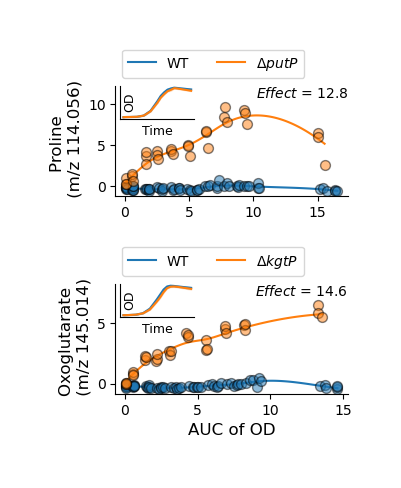

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(3, 4), constrained_layout=False, sharex=False)
axes = axes.flatten()
data_to_plot = [
    ['putP','Proline', 2], 
    ['kgtP','Oxoglutarate', 5]
]
xval = 'AUC OD'
for i, (strain_str, metabolite, batch) in enumerate(data_to_plot):
    strains = ['WT'] + strain_str.split(';')
    ionMz = name_to_ionMz[metabolite]
    plot_timecourse_difference(axes[i], df, [batch], strains, ionMz, xval=xval, yval='Median Z-score', ystd='Z-score std')
    # axes[i].set_title(f'm/z {ionMz[0]:.3f} - {metabolite}', size = 10)
    axes[i].set_ylabel(f'{metabolite} \n (m/z {ionMz[0]:.3f})', size = 12)
    axes[i].set_ylim(axes[i].get_ylim()[0], axes[i].get_ylim()[1]*1.2)
    effect = np.mean(sel_df.loc[(sel_df.Strain == strains[1])&(sel_df.ionMz.isin(ionMz)), 'Rel. distance'].values)
    axes[i].text(1, 1, f'$Effect$ = {effect:.1f}', transform=axes[i].transAxes, size=10, weight='regular', ha = 'right', va = 'top')
    # --- OD curve inset ---
    inset_ax = axes[i].inset_axes([0.02, 0.7, 0.32, 0.3])  # [x0, y0, width, height]
    od_data = od_df.loc[od_df.Strain.isin(strains)&od_df.Batch.isin([batch])]
    l = sns.lineplot(data = od_data, x = 'Hours', y = 'OD', hue = 'Strain',hue_order = strains, ax = inset_ax)
    sns.despine(ax = inset_ax)
    inset_ax.set_xticks([])
    inset_ax.set_yticks([])
    inset_ax.set_ylabel('OD', labelpad = -12, size = 9)
    inset_ax.set_xlabel('Time', size = 9)
    # inset_ax.yaxis.set_label_position('right')
    # inset_ax.set_title('OD', fontsize=8)
    # inset_ax.legend(fontsize=6, loc='upper left', frameon=False)
    # inset_ax.get_legend_handles_labels()
    
    handles, labels = inset_ax.get_legend_handles_labels()
    labels = [f'Δ${lbl}$' if lbl != 'WT' else 'WT' for lbl in labels]
    legend = inset_ax.legend(handles, labels, fontsize=10, loc='lower left', bbox_transform = axes[i].transAxes, 
    frameon=True, ncol=2, bbox_to_anchor=[0,1.01])
    legend.set_title(None)  # Remove legend title
    

# fig.supylabel('Median Z-score', x=-0.15, y=0.5, rotation=90, size = 12)
if xval == 'Hours':
    axes[-1].set_xlabel('Time [h]', size = 12)
else:
    axes[-1].set_xlabel('AUC of OD', size = 12)
sns.despine()
plt.subplots_adjust(hspace=0.8)
plt.savefig(figure_folder / f'figure_5_putP_kgtP_transporterKO_timecourses_{normalization}_norm_lam_{lam}_{xval}.png', dpi=300, bbox_inches='tight')
plt.savefig(figure_folder / f'figure_5_putP_kgtP_transporterKO_timecourses_{normalization}_norm_lam_{lam}_{xval}.pdf', dpi=300, bbox_inches='tight')

## Glutamate

In [19]:
df.loc[df.Strain.isin(['gltS', 'gltP', 'gadC', 'gltJ']), 'Batch'].unique()

array([2., 3., 4.])

In [20]:
dis_df.loc[dis_df.ionMz.isin(name_to_ionMz['Glutamic acid'])&(dis_df.Strain.isin(['gltP','gltS','gltJ','gadC']))]

,Strain,ionMz,Rel. abs. distance,Rel. distance,Mean abs. distance,Mean distance,MAE1,MAE2,Mean MAE,Strain 1,Strain 2,p-value rel,p-value abs
3517,gltJ,146.046,1.157720,0.017203,0.197375,0.002933,0.068799,0.272173,0.170486,gltJ,WT,0.463,0.02
7453,gltP,146.046,5.349006,5.182146,3.416001,3.309441,0.971343,0.305904,0.638624,gltP,WT,0.000,0.00
7945,gadC,146.046,2.170204,2.166315,0.855320,0.853787,0.482335,0.305904,0.394120,gadC,WT,0.000,0.00
12127,gltS,146.046,5.813300,5.813300,1.699339,1.699339,0.263067,0.321571,0.292319,gltS,WT,0.000,0.00


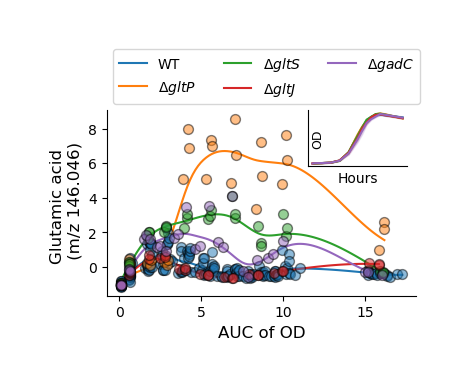

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3), constrained_layout=False, sharex=True)
# axes = axes.flatten()
data_to_plot = [
    ['gltP;gltS;gltJ;gadC','Glutamic acid', [2,3,4]], 
]
yval = 'Median Z-score'
ystd = 'Z-score std'
for j, (strain_str, metabolite, batch) in enumerate(data_to_plot):
    strains = ['WT'] + strain_str.split(';')
    ionMz = name_to_ionMz[metabolite]
    data = df.loc[df.ionMz.isin(ionMz)&(df.Strain.isin(strains))&(df['Batch'].isin(batch))].copy()
    data.sort_values(by=['Strain', xval], inplace=True)
    # plot_timecourse_difference(ax, df, [batch], strains, ionMz, xval='Hours', yval='Median Z-score', ystd='Z-score std')

    for i, strain in enumerate(strains):
        strain_data = data.loc[data.Strain == strain].copy()
        strain_data.sort_values(by=[xval], inplace=True)
        is_duplicated = strain_data[xval].duplicated()
        if np.any(is_duplicated):
            strain_data.loc[is_duplicated, xval] += sorted(np.random.normal(0, 1e-2, size=is_duplicated.sum()))
        strain_data.sort_values(by=xval, inplace=True)
        x = strain_data[xval].values
        y = strain_data[yval].values
        y_std = strain_data[ystd].values
        spline = make_smoothing_spline(x, y, w = 1/y_std, lam = lam)
        xarr = np.linspace(x.min(), x.max(), 100, endpoint=True)
        
        ax.plot(xarr, spline(xarr), color=f'C{i}', zorder = 0)
        label = f'Δ${strain}$' if strain != 'WT' else 'WT'

        ax.scatter(x, y, color=f'C{i}', label=label, alpha = 0.5, edgecolor='k', s=50)


    inset_ax = ax.inset_axes([0.65, 0.7, 0.32, 0.3])  # [x0, y0, width, height]
    od_data = od_df.loc[od_df.Strain.isin(strains)&od_df.Batch.isin(batch)]
    l = sns.lineplot(data = od_data, x = 'Hours', y = 'OD', hue = 'Strain', hue_order = strains, ax = inset_ax)
    sns.despine(ax = inset_ax)
    inset_ax.set_xticks([])
    inset_ax.set_yticks([])
    inset_ax.set_ylabel('OD', labelpad = -12, size = 9)
    handles, labels = inset_ax.get_legend_handles_labels()
    labels = [f'Δ${lbl}$' if lbl != 'WT' else 'WT' for lbl in labels]
    legend = inset_ax.legend(handles, labels, fontsize=10, loc='lower left', bbox_transform = ax.transAxes,
                             frameon=True, ncol=3, bbox_to_anchor=[0,1])
    legend.set_title(None)  # Remove legend title
    
# ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
# ax.set_title(f'm/z {ionMz[0]:.3f} - {metabolite}', size = 10)
ax.set_ylabel(f'{metabolite} \n (m/z {ionMz[0]:.3f})', size = 12)
plt.tight_layout()

# fig.supylabel('Median Z-score', x=-0.01, y=0.5, rotation=90, size = 12)
if xval == 'Hours':
    ax.set_xlabel('Time [h]')
else:
    ax.set_xlabel('AUC of OD', size = 12)
sns.despine()
plt.savefig(figure_folder / f'figure_5_glutamate_transporterKO_timecourses_{normalization}_norm_lam_{lam}_{xval}.png', dpi=300, bbox_inches='tight')
plt.savefig(figure_folder / f'figure_5_glutamate_transporterKO_timecourses_{normalization}_norm_lam_{lam}_{xval}.pdf', dpi=300, bbox_inches='tight')

# glnP

In [22]:
sel_df.loc[sel_df.Strain == 'glnP'].sort_values('Rel. abs. distance', ascending=False).head(15)

,Strain,ionMz,Rel. abs. distance,Rel. distance,Mean abs. distance,Mean distance,MAE1,MAE2,Mean MAE,Strain 1,Strain 2,p-value rel,p-value abs,Metabolite,KEGG,All metabolite names,Alt. annotations,Classes,Classification
8399,glnP,116.0718,16.356380,16.303102,2.696068,2.687286,0.162066,0.167599,0.164833,glnP,WT,0.0,0.0,Valine,C00183;C00719,Betaine / Valine,Betaine,Amino acids,Amino acids
8384,glnP,103.0400,14.226584,14.160707,2.564532,2.552656,0.218400,0.142127,0.180263,glnP,WT,0.0,0.0,Hydroxybutanoic acid,C00989;C01089;C01188;C01991,Hydroxybutanoic acid / 3-Hydroxyisobutyric aci...,3-Hydroxyisobutyric acid / 4-Hydroxybutanoic a...,Lipid-like molecules,Lipid-like molecules
8383,glnP,102.0562,13.921373,13.921373,3.986957,3.986957,0.347865,0.224918,0.286391,glnP,WT,0.0,0.0,Aminobutanoic acid (ABA),C00334;C01026;C03284;C03665,Aminobutanoic acid (ABA) / 2-Aminoisobutyric a...,"2-Aminoisobutyric acid / N,N-Dimethylglycine /...",Amino acids,Amino acids
8439,glnP,147.0664,13.065258,-13.065258,1.395974,-1.395974,0.059313,0.154379,0.106846,glnP,WT,0.0,0.0,"(R) 2,3-Dihydroxy-3-methylvalerate",C00522;C06007,"(R) 2,3-Dihydroxy-3-methylvalerate / (R)-Pantoate",(R)-Pantoate,Lipid-like molecules,Lipid-like molecules
8424,glnP,133.0508,12.418101,-12.418101,1.316825,-1.316825,0.048885,0.163196,0.106041,glnP,WT,0.0,0.0,Deoxyribose,C01801;C04039;C04272;C06257,"(R)-2,3-Dihydroxy-isovalerate / 1-Deoxy-xylulo...","(R)-2,3-Dihydroxy-isovalerate / 1-Deoxy-xylulo...",Organic oxygen compounds;Lipid-like molecules,Mixed
8418,glnP,130.0876,10.045373,10.034978,1.056213,1.055120,0.090679,0.119609,0.105144,glnP,WT,0.0,0.0,(Iso)Leucine,C00123;C00407,Isoleucine / (Iso)Leucine,Isoleucine,Amino acids,Amino acids
8578,glnP,344.0400,8.106058,-7.999136,0.418381,-0.412862,0.038405,0.064822,0.051613,glnP,WT,0.0,0.0,cGMP,C00942;C06194,"cGMP / Guanosine 2',3'-cyclic phosphate","Guanosine 2',3'-cyclic phosphate",Nucleotides / nucleosides,Nucleotides / nucleosides
8471,glnP,170.0454,7.455470,7.455470,1.425412,1.425412,0.158978,0.223402,0.191190,glnP,WT,0.0,0.0,"2,3,4,5-Tetrahydrodipicolinate",C03972,"2,3,4,5-Tetrahydrodipicolinate",NaN,Amino acids,Amino acids
8371,glnP,75.0089,7.350980,-7.350980,1.692491,-1.692491,0.201369,0.259112,0.230240,glnP,WT,0.0,0.0,Glycolate,C00160,Glycolate,NaN,Unknown,Unknown
8486,glnP,178.0510,6.195222,-6.182014,0.634606,-0.633253,0.036812,0.168058,0.102435,glnP,WT,0.0,0.0,N-Acetylanthranilate,C06332,N-Acetylanthranilate,NaN,Benzenoids,Other


In [23]:
name_to_ionMz['Hydroxybutanoic acid']

[103.0402, 103.04]

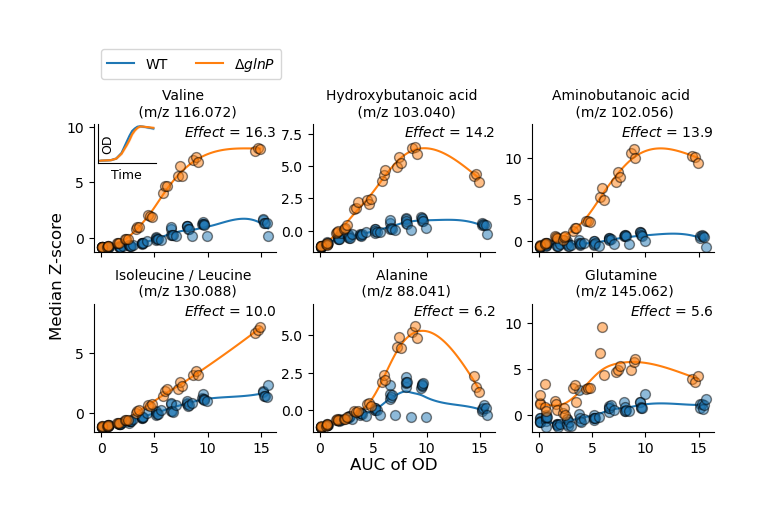

In [24]:
fig, axes = plt.subplots(2,3 , figsize=(8, 4), constrained_layout=False, sharex=True)
axes = axes.flatten()
data_to_plot = [
    ['glnP','Valine', 3], 
    ['glnP','Hydroxybutanoic acid', 3],
    ['glnP','Aminobutanoic acid (ABA)', 3],
    # ['glnP','Deoxyribose', 3],
    ['glnP','(Iso)Leucine', 3],
    ['glnP','Alanine', 3],
    # ['glnP','Cyclic GMP', 3],
    ['glnP','Glutamine', 3],
]

rename_dict = {
    'Valine': 'Valine',
    'Hydroxybutanoic acid': 'Hydroxybutanoic acid',
    'Aminobutanoic acid (ABA)': 'Aminobutanoic acid',
    '(Iso)Leucine': 'Isoleucine / Leucine',
    'Alanine': 'Alanine',
    'Glutamine': 'Glutamine'
}
xval = 'AUC OD'
for i, (strain_str, metabolite, batch) in enumerate(data_to_plot):
    strains = ['WT'] + strain_str.split(';')
    ionMz = name_to_ionMz[metabolite]
    plot_timecourse_difference(axes[i], df, [batch], strains, ionMz, xval=xval, yval='Median Z-score', ystd='Z-score std')
    axes[i].set_title(f'{rename_dict[metabolite]} \n (m/z {ionMz[0]:.3f})', size = 10)
    # axes[i].set_ylabel(f'{rename_dict[metabolite]} \n (m/z {ionMz[0]:.3f})', size = 10)
    axes[i].set_ylim(axes[i].get_ylim()[0], axes[i].get_ylim()[1]*1.2)
    effect = np.mean(sel_df.loc[(sel_df.Strain == strains[1])&(sel_df.ionMz.isin(ionMz)), 'Rel. distance'].values)
    axes[i].text(1, 1, f'$Effect$ = {effect:.1f}', transform=axes[i].transAxes, size=10, weight='regular', ha = 'right', va = 'top')
    # --- OD curve inset ---
    if i == 0:
        inset_ax = axes[i].inset_axes([0.02, 0.7, 0.32, 0.3])  # [x0, y0, width, height]
        od_data = od_df.loc[od_df.Strain.isin(strains)&od_df.Batch.isin([batch])].copy()
        l = sns.lineplot(data = od_data, x = 'Hours', y = 'OD', hue = 'Strain',hue_order=strains, ax = inset_ax)
        sns.despine(ax = inset_ax)
        inset_ax.set_xticks([])
        inset_ax.set_yticks([])
        inset_ax.set_ylabel('OD', labelpad = -12, size = 9)
        inset_ax.set_xlabel('Time', size = 9)
        # inset_ax.yaxis.set_label_position('right')
        # inset_ax.set_title('OD', fontsize=8)
        # inset_ax.legend(fontsize=6, loc='upper left', frameon=False)
        # inset_ax.get_legend_handles_labels()
        
        handles, labels = inset_ax.get_legend_handles_labels()
        labels = [f'Δ${lbl}$' if lbl != 'WT' else 'WT' for lbl in labels]
        legend = inset_ax.legend(handles, labels, fontsize=10, loc='lower left', bbox_transform = axes[i].transAxes,
                frameon=True, ncol=2, bbox_to_anchor=[0,1.3])
        legend.set_title(None)  # Remove legend title
        

fig.supylabel('Median Z-score', x=0.07, y=0.5, rotation=90, size = 12)
if xval == 'Hours':
    fig.supxlabel('Time [h]', size = 12)
else:
    fig.supxlabel('AUC of OD', size = 12)

sns.despine()
plt.subplots_adjust(hspace=0.4, right = 0.9, wspace = 0.2)
plt.savefig(figure_folder / f'figure_5_ED_glnP_transporterKO_timecourses_{normalization}_norm_lam_{lam}_{xval}.png', dpi=300, bbox_inches='tight')
plt.savefig(figure_folder / f'figure_5_ED_glnP_transporterKO_timecourses_{normalization}_norm_lam_{lam}_{xval}.pdf', dpi=300, bbox_inches='tight')

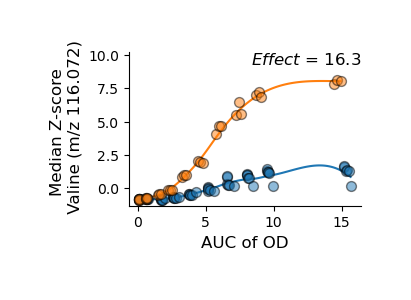

In [25]:
fig, ax = plt.subplots(1,1, figsize=(3, 2), constrained_layout=False, sharex=True)
data_to_plot = [
    ['glnP','Valine', 3], 
]
xval = 'AUC OD'
for i, (strain_str, metabolite, batch) in enumerate(data_to_plot):
    strains = ['WT'] + strain_str.split(';')
    ionMz = name_to_ionMz[metabolite]
    plot_timecourse_difference(ax, df, [batch], strains, ionMz, xval=xval, yval='Median Z-score', ystd='Z-score std')
    # axes[i].set_title(f'm/z {ionMz[0]:.3f} \n {rename_dict[metabolite]}', size = 10)
    ax.set_ylabel(f'{rename_dict[metabolite]} \n (m/z {ionMz[0]:.3f})', size = 10)
    ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1]*1.2)
    effect = np.mean(sel_df.loc[(sel_df.Strain == strains[1])&(sel_df.ionMz.isin(ionMz)), 'Rel. distance'].values)
    ax.text(1, 1, f'$Effect$ = {effect:.1f}', transform=ax.transAxes, size=12, weight='regular', ha = 'right', va = 'top')
        

plt.xlabel('AUC of OD', size = 12)
plt.ylabel(f'Median Z-score \n Valine (m/z {ionMz[0]:.3f})', size = 12)
# plt.text(1,1, f'Valine (m/z {ionMz[0]:.3f})', size = 12)
sns.despine()
# plt.subplots_adjust(hspace=0.2, right = 0.9, wspace = 0.6)
plt.savefig(figure_folder / f'figure_5_valine_glnP_transporterKO_timecourses_{normalization}_norm_lam_{lam}_{xval}.png', dpi=300, bbox_inches='tight')
plt.savefig(figure_folder / f'figure_5_valine_glnP_transporterKO_timecourses_{normalization}_norm_lam_{lam}_{xval}.pdf', dpi=300, bbox_inches='tight')

# Negative effects

In [26]:
mz_to_name = {}
for key, value_list in name_to_ionMz.items():
    for mz in value_list:
        mz_to_name[mz] = key

In [27]:
dis_mz['Name'] = dis_mz.ionMz.map(mz_to_name)

In [28]:
dis_mz.sort_values(by='Rel. distance').tail(20)

,Strain,ionMz,Rel. abs. distance,Rel. distance,Mean abs. distance,Mean distance,MAE1,MAE2,Mean MAE,Strain 1,Strain 2,p-value rel,p-value abs,Metabolite,KEGG,All metabolite names,Alt. annotations,Classes,Classification,Name
4978,adeP,132.0305,8.547974,8.547974,1.011552,1.011552,0.154629,0.082047,0.118338,adeP,WT,0.0,0.0,Aspartate,C00049,Aspartate,NaN,Amino acids,Amino acids,Aspartate
1690,ompC,344.0400,9.073739,9.061621,0.356801,0.356325,0.048346,0.030299,0.039322,ompC,WT,0.0,0.0,cGMP,C00942;C06194,"cGMP / Guanosine 2',3'-cyclic phosphate","Guanosine 2',3'-cyclic phosphate",Nucleotides / nucleosides,Nucleotides / nucleosides,"Guanosine 2',3'-cyclic phosphate"
11369,rhtC,130.0511,9.197182,9.184187,1.700069,1.697666,0.138408,0.231286,0.184847,rhtC,WT,0.0,0.0,5-Aminolevulinic acid,C00430;C01157;C01165;C03741,(S)-4-Amino-5-oxopentanoate / 5-Aminolevulinic...,(S)-4-Amino-5-oxopentanoate / Glutamic-gamma-s...,Amino acids,Amino acids,Hydroxyproline
13208,cstA,240.0514,9.363082,9.289963,1.805048,1.790952,0.193738,0.191829,0.192784,cstA,WT,0.0,0.0,"N-(2,3-Dihydroxybenzoyl)-L-serine",C04204,"N-(2,3-Dihydroxybenzoyl)-L-serine",NaN,Unknown,Unknown,"N-(2,3-Dihydroxybenzoyl)-L-serine"
3110,ygaZ,218.1034,9.390354,9.349348,1.069362,1.064692,0.170979,0.056778,0.113879,ygaZ,WT,0.0,0.0,Pantothenate,C00864,Pantothenate,NaN,Amino acids,Amino acids,Pantothenate
11374,rhtC,132.0305,9.389308,9.389308,1.293564,1.293564,0.130658,0.144882,0.137770,rhtC,WT,0.0,0.0,Aspartate,C00049,Aspartate,NaN,Amino acids,Amino acids,Aspartate
13139,cstA,166.0507,9.537453,9.537453,2.446404,2.446404,0.303225,0.209785,0.256505,cstA,WT,0.0,0.0,Pyridoxal,C00250,Pyridoxal,NaN,Organoheterocyclic compounds,Organoheterocyclic compounds,Pyridoxal
5038,adeP,175.0364,9.667752,9.667752,1.067742,1.067742,0.128909,0.091979,0.110444,adeP,WT,0.0,0.0,Ureidosuccinic acid,C00438,Ureidosuccinic acid,NaN,Amino acids,Amino acids,Ureidosuccinic acid
13254,cstA,347.0398,9.845191,9.840073,2.364688,2.363459,0.302512,0.177862,0.240187,cstA,WT,0.0,0.0,IMP,C00130,Inosinic acid,Inosinic acid,Nucleotides / nucleosides,Nucleotides / nucleosides,IMP
11431,rhtC,174.0409,9.975786,9.970862,1.898819,1.897882,0.138635,0.242050,0.190343,rhtC,WT,0.0,0.0,Acetyl-Asp,C01042,Acetyl-Asp,NaN,Unknown,Unknown,Acetyl-Asp


In [29]:
dis_mz.loc[dis_mz.Strain=='glnP'].sort_values(by='Rel. distance').tail(10)

,Strain,ionMz,Rel. abs. distance,Rel. distance,Mean abs. distance,Mean distance,MAE1,MAE2,Mean MAE,Strain 1,Strain 2,p-value rel,p-value abs,Metabolite,KEGG,All metabolite names,Alt. annotations,Classes,Classification,Name
8516,glnP,213.0161,5.228956,5.020171,1.200428,1.152496,0.188925,0.270221,0.229573,glnP,WT,0.0,0.0,2-Deoxy-D-ribose 1-phosphate,C00672;C00673;C11437,1-Deoxy-xylulose 5-phosphate / 2-Deoxy-D-ribos...,1-Deoxy-xylulose 5-phosphate / Deoxyribose 5-p...,Organic oxygen compounds;Other organic acids,Mixed,Deoxyribose 5-phosphate
8376,glnP,89.0247,5.096973,5.056652,1.673555,1.660316,0.270198,0.386488,0.328343,glnP,WT,0.0,0.0,Lactate,C00184;C00186;C00256;C00577;C01013;C02426,3-Hydroxypropanoate / Dihydroxyacetone / Glyce...,3-Hydroxypropanoate / Dihydroxyacetone / Glyce...,Keto / hydroxy acids;Organic oxygen compounds,Mixed,Lactate
8495,glnP,188.0566,5.282495,5.282495,0.856768,0.856768,0.129445,0.194935,0.162190,glnP,WT,0.0,0.0,Acetyl-Glu,C00624,Acetyl-Glu,NaN,Amino acids,Amino acids,Acetyl-Glu
8434,glnP,145.0621,5.570460,5.570460,3.236832,3.236832,0.807215,0.354926,0.581071,glnP,WT,0.0,0.0,Glutamine,C00064;C00819;C05100,Glutamine / Ureidoisobutyric acid,Ureidoisobutyric acid,Amino acids,Amino acids,Ureidoisobutyric acid
8375,glnP,88.0406,6.180386,6.180386,1.279179,1.279179,0.153337,0.260610,0.206974,glnP,WT,0.0,0.0,Alanine,C00041;C00099;C00133;C00213,Alanine / Sarcosine / beta-Alanine,Sarcosine / beta-Alanine,Amino acids,Amino acids,beta-Alanine
8471,glnP,170.0454,7.455470,7.455470,1.425412,1.425412,0.158978,0.223402,0.191190,glnP,WT,0.0,0.0,"2,3,4,5-Tetrahydrodipicolinate",C03972,"2,3,4,5-Tetrahydrodipicolinate",NaN,Amino acids,Amino acids,"2,3,4,5-Tetrahydrodipicolinate"
8418,glnP,130.0876,10.045373,10.034978,1.056213,1.055120,0.090679,0.119609,0.105144,glnP,WT,0.0,0.0,(Iso)Leucine,C00123;C00407,Isoleucine / (Iso)Leucine,Isoleucine,Amino acids,Amino acids,(Iso)Leucine
8383,glnP,102.0562,13.921373,13.921373,3.986957,3.986957,0.347865,0.224918,0.286391,glnP,WT,0.0,0.0,Aminobutanoic acid (ABA),C00334;C01026;C03284;C03665,Aminobutanoic acid (ABA) / 2-Aminoisobutyric a...,"2-Aminoisobutyric acid / N,N-Dimethylglycine /...",Amino acids,Amino acids,gamma-Aminobutyric acid
8384,glnP,103.0400,14.226584,14.160707,2.564532,2.552656,0.218400,0.142127,0.180263,glnP,WT,0.0,0.0,Hydroxybutanoic acid,C00989;C01089;C01188;C01991,Hydroxybutanoic acid / 3-Hydroxyisobutyric aci...,3-Hydroxyisobutyric acid / 4-Hydroxybutanoic a...,Lipid-like molecules,Lipid-like molecules,gamma-Hydroxybutyrate
8399,glnP,116.0718,16.356380,16.303102,2.696068,2.687286,0.162066,0.167599,0.164833,glnP,WT,0.0,0.0,Valine,C00183;C00719,Betaine / Valine,Betaine,Amino acids,Amino acids,Valine


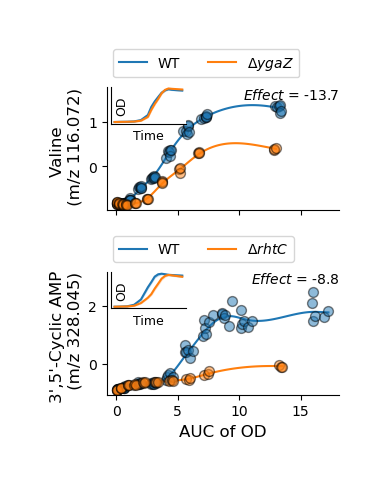

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(3, 4), constrained_layout=False, sharex=True)
axes = axes.flatten()
data_to_plot = [
    ['ygaZ','Valine', 1], 
    ['rhtC',"3',5'-Cyclic AMP", 4]
]
xval = 'AUC OD'
for i, (strain_str, metabolite, batch) in enumerate(data_to_plot):
    strains = ['WT'] + strain_str.split(';')
    ionMz = name_to_ionMz[metabolite]
    plot_timecourse_difference(axes[i], df, [batch], strains, ionMz, xval=xval, yval='Median Z-score', ystd='Z-score std')
    # axes[i].set_title(f'm/z {ionMz[0]:.3f} - {metabolite}', size = 10)
    axes[i].set_ylabel(f'{metabolite} \n (m/z {ionMz[0]:.3f})', size = 12)
    axes[i].set_ylim(axes[i].get_ylim()[0], axes[i].get_ylim()[1]*1.2)
    effect = np.mean(sel_df.loc[(sel_df.Strain == strains[1])&(sel_df.ionMz.isin(ionMz)), 'Rel. distance'].values)
    axes[i].text(1, 1, f'$Effect$ = {effect:.1f}', transform=axes[i].transAxes, size=10, weight='regular', ha = 'right', va = 'top')

    # --- OD curve inset ---
    inset_ax = axes[i].inset_axes([0.02, 0.7, 0.32, 0.3])  # [x0, y0, width, height]

    od_data = od_df.loc[od_df.Strain.isin(strains)&od_df.Batch.isin([batch])]
    l = sns.lineplot(data = od_data, x = 'Hours', y = 'OD', hue = 'Strain', hue_order=strains, ax = inset_ax)
    sns.despine(ax = inset_ax)
    inset_ax.set_xticks([])
    inset_ax.set_yticks([])
    inset_ax.set_ylabel('OD', labelpad = -12, size = 9)
    inset_ax.set_xlabel('Time', size = 9)
    # inset_ax.yaxis.set_label_position('right')
    # inset_ax.set_title('OD', fontsize=8)
    # inset_ax.legend(fontsize=6, loc='upper left', frameon=False)
    # inset_ax.get_legend_handles_labels()
    
    handles, labels = inset_ax.get_legend_handles_labels()
    labels = [f'Δ${lbl}$' if lbl != 'WT' else 'WT' for lbl in labels]
    legend = inset_ax.legend(handles, labels, fontsize=10, loc='lower left',bbox_transform = axes[i].transAxes,
                             frameon=True, ncol=2, bbox_to_anchor=[0,1.02])
    legend.set_title(None)  # Remove legend title
    

# fig.supylabel('Median Z-score', x=-0.04, y=0.5, rotation=90, size = 12)
if xval == 'Hours':
    axes[-1].set_xlabel('Time [h]', size = 12)
else:
    axes[-1].set_xlabel('AUC of OD', size = 12)
sns.despine()
plt.subplots_adjust(hspace=0.5)
plt.savefig(figure_folder / f'figure_5_ygaZ_rhtC_transporterKO_timecourses_{normalization}_norm_lam_{lam}_{xval}.png', dpi=300, bbox_inches='tight')
plt.savefig(figure_folder / f'figure_5_ygaZ_rhtC_transporterKO_timecourses_{normalization}_norm_lam_{lam}_{xval}.pdf', dpi=300, bbox_inches='tight')

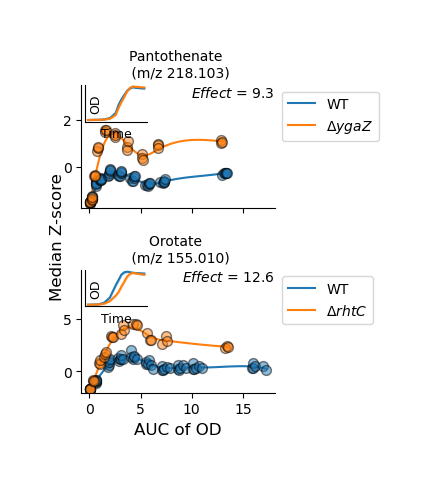

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(2.5, 4), constrained_layout=False, sharex=True)
axes = axes.flatten()
data_to_plot = [
    ['ygaZ','Pantothenate', 1], 
    ['rhtC',"Orotate", 4]
]
xval = 'AUC OD'
for i, (strain_str, metabolite, batch) in enumerate(data_to_plot):
    strains = ['WT'] + strain_str.split(';')
    ionMz = name_to_ionMz[metabolite]
    plot_timecourse_difference(axes[i], df, [batch], strains, ionMz, xval=xval, yval='Median Z-score', ystd='Z-score std')
    axes[i].set_title(f'{metabolite} \n (m/z {ionMz[0]:.3f})', size = 10)
    # axes[i].set_ylabel(f'{metabolite} \n (m/z {ionMz[0]:.3f})', size = 12)
    axes[i].set_ylim(axes[i].get_ylim()[0], axes[i].get_ylim()[1]*2)
    effect = np.mean(sel_df.loc[(sel_df.Strain == strains[1])&(sel_df.ionMz.isin(ionMz)), 'Rel. distance'].values)
    axes[i].text(1, 1, f'$Effect$ = {effect:.1f}', transform=axes[i].transAxes, size=10, weight='regular', ha = 'right', va = 'top')

    # --- OD curve inset ---
    inset_ax = axes[i].inset_axes([0.02, 0.7, 0.32, 0.3])  # [x0, y0, width, height]

    od_data = od_df.loc[od_df.Strain.isin(strains)&od_df.Batch.isin([batch])]
    l = sns.lineplot(data = od_data, x = 'Hours', y = 'OD', hue = 'Strain', hue_order=strains, ax = inset_ax)
    sns.despine(ax = inset_ax)
    inset_ax.set_xticks([])
    inset_ax.set_yticks([])
    inset_ax.set_ylabel('OD', labelpad = -12, size = 9)
    inset_ax.set_xlabel('Time', size = 9)
    # inset_ax.yaxis.set_label_position('right')
    # inset_ax.set_title('OD', fontsize=8)
    # inset_ax.legend(fontsize=6, loc='upper left', frameon=False)
    # inset_ax.get_legend_handles_labels()
    
    handles, labels = inset_ax.get_legend_handles_labels()
    labels = [f'Δ${lbl}$' if lbl != 'WT' else 'WT' for lbl in labels]
    legend = inset_ax.legend(handles, labels, fontsize=10, loc='upper left',bbox_transform = axes[i].transAxes,
                             frameon=True, ncol=1, bbox_to_anchor=[1,1.])
    legend.set_title(None)  # Remove legend title
    

fig.supylabel('Median Z-score', x=-0.0, y=0.5, rotation=90, size = 12)
if xval == 'Hours':
    axes[-1].set_xlabel('Time [h]', size = 12)
else:
    axes[-1].set_xlabel('AUC of OD', size = 12)
sns.despine()
plt.subplots_adjust(hspace=0.5)
plt.savefig(figure_folder / f'figure_5_ED_ygaZ_rhtC_transporterKO_timecourses_{normalization}_norm_lam_{lam}_{xval}.png', dpi=300, bbox_inches='tight')
plt.savefig(figure_folder / f'figure_5_ED_ygaZ_rhtC_transporterKO_timecourses_{normalization}_norm_lam_{lam}_{xval}.pdf', dpi=300, bbox_inches='tight')

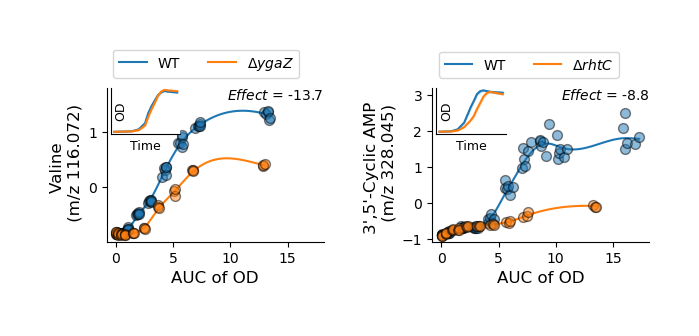

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(7, 2), constrained_layout=False, sharex=True)
axes = axes.flatten()
data_to_plot = [
    ['ygaZ','Valine', 1], 
    ['rhtC',"3',5'-Cyclic AMP", 4]
]
xval = 'AUC OD'
for i, (strain_str, metabolite, batch) in enumerate(data_to_plot):
    strains = ['WT'] + strain_str.split(';')
    ionMz = name_to_ionMz[metabolite]
    plot_timecourse_difference(axes[i], df, [batch], strains, ionMz, xval=xval, yval='Median Z-score', ystd='Z-score std')
    # axes[i].set_title(f'm/z {ionMz[0]:.3f} - {metabolite}', size = 10)
    axes[i].set_ylabel(f'{metabolite} \n (m/z {ionMz[0]:.3f})', size = 12)
    axes[i].set_ylim(axes[i].get_ylim()[0], axes[i].get_ylim()[1]*1.2)
    effect = np.mean(sel_df.loc[(sel_df.Strain == strains[1])&(sel_df.ionMz.isin(ionMz)), 'Rel. distance'].values)
    axes[i].text(1, 1, f'$Effect$ = {effect:.1f}', transform=axes[i].transAxes, size=10, weight='regular', ha = 'right', va = 'top')

    # --- OD curve inset ---
    inset_ax = axes[i].inset_axes([0.02, 0.7, 0.32, 0.3])  # [x0, y0, width, height]

    od_data = od_df.loc[od_df.Strain.isin(strains)&od_df.Batch.isin([batch])]
    l = sns.lineplot(data = od_data, x = 'Hours', y = 'OD', hue = 'Strain', hue_order=strains, ax = inset_ax)
    sns.despine(ax = inset_ax)
    inset_ax.set_xticks([])
    inset_ax.set_yticks([])
    inset_ax.set_ylabel('OD', labelpad = -12, size = 9)
    inset_ax.set_xlabel('Time', size = 9)
    # inset_ax.yaxis.set_label_position('right')
    # inset_ax.set_title('OD', fontsize=8)
    # inset_ax.legend(fontsize=6, loc='upper left', frameon=False)
    # inset_ax.get_legend_handles_labels()
    
    handles, labels = inset_ax.get_legend_handles_labels()
    labels = [f'Δ${lbl}$' if lbl != 'WT' else 'WT' for lbl in labels]
    legend = inset_ax.legend(handles, labels, fontsize=10, loc='lower left',bbox_transform = axes[i].transAxes,
                             frameon=True, ncol=2, bbox_to_anchor=[0,1.02])
    legend.set_title(None)  # Remove legend title
    axes[i].set_xlabel('AUC of OD', size = 12)

# fig.supylabel('Median Z-score', x=-0.04, y=0.5, rotation=90, size = 12)
# if xval == 'Hours':
#     fig.supxlabel('Time [h]', size = 12, )
# else:
#     fig.supxlabel('AUC of OD', size = 12, y = -0.1)

sns.despine()
plt.subplots_adjust(wspace=0.5)
# plt.savefig(figure_folder / f'figure_5_ygaZ_rhtC_transporterKO_h_timecourses_{normalization}_norm_lam_{lam}_{xval}.png', dpi=300, bbox_inches='tight')
plt.savefig(figure_folder / f'figure_5_ygaZ_rhtC_transporterKO_h_timecourses_{normalization}_norm_lam_{lam}_{xval}.pdf', dpi=300, bbox_inches='tight')

In [35]:
dis_mz.sort_values(by='Rel. distance').head(10)
# df.loc[df.Strain.isin(['punC', 'adeP']), 'Batch'].unique()

,Strain,ionMz,Rel. abs. distance,Rel. distance,Mean abs. distance,Mean distance,MAE1,MAE2,Mean MAE,Strain 1,Strain 2,p-value rel,p-value abs,Metabolite,KEGG,All metabolite names,Alt. annotations,Classes,Classification,Name
460,punC,344.0400,18.419066,-18.103784,0.397405,-0.390603,0.012852,0.030299,0.021576,punC,WT,0.0,0.0,cGMP,C00942;C06194,"cGMP / Guanosine 2',3'-cyclic phosphate","Guanosine 2',3'-cyclic phosphate",Nucleotides / nucleosides,Nucleotides / nucleosides,"Guanosine 2',3'-cyclic phosphate"
2987,ygaZ,116.0718,13.707820,-13.683664,0.346247,-0.345637,0.021188,0.029330,0.025259,ygaZ,WT,0.0,0.0,Valine,C00183;C00719,Betaine / Valine,Betaine,Amino acids,Amino acids,Valine
8439,glnP,147.0664,13.065258,-13.065258,1.395974,-1.395974,0.059313,0.154379,0.106846,glnP,WT,0.0,0.0,"(R) 2,3-Dihydroxy-3-methylvalerate",C00522;C06007,"(R) 2,3-Dihydroxy-3-methylvalerate / (R)-Pantoate",(R)-Pantoate,Lipid-like molecules,Lipid-like molecules,(R)-Pantoate
450,punC,322.0444,13.106362,-13.049091,0.506991,-0.504775,0.019417,0.057949,0.038683,punC,WT,0.0,0.0,CMP,C00055;C05822,3'-CMP / Cytidine monophosphate,3'-CMP / Cytidine monophosphate,Nucleotides / nucleosides,Nucleotides / nucleosides,CMP
8424,glnP,133.0508,12.418101,-12.418101,1.316825,-1.316825,0.048885,0.163196,0.106041,glnP,WT,0.0,0.0,Deoxyribose,C01801;C04039;C04272;C06257,"(R)-2,3-Dihydroxy-isovalerate / 1-Deoxy-xylulo...","(R)-2,3-Dihydroxy-isovalerate / 1-Deoxy-xylulo...",Organic oxygen compounds;Lipid-like molecules,Mixed,Deoxyribose
465,punC,362.0506,12.389385,-12.183928,0.523613,-0.514929,0.023410,0.061116,0.042263,punC,WT,0.0,0.0,GMP,C00144;C06193;C18239;C19968,8-oxo-dGMP / Cyclic pyranopterin monophosphate...,8-oxo-dGMP / Cyclic pyranopterin monophosphate...,Nucleotides / nucleosides;Organoheterocyclic c...,Mixed,GMP
3067,ygaZ,174.0409,11.365912,-11.313851,0.669483,-0.666417,0.044974,0.072832,0.058903,ygaZ,WT,0.0,0.0,Acetyl-Asp,C01042,Acetyl-Asp,NaN,Unknown,Unknown,Acetyl-Asp
440,punC,304.0351,11.582395,-10.579716,0.437867,-0.399961,0.027195,0.048414,0.037805,punC,WT,0.0,0.0,"3',5'-Cyclic CMP",C02354,"3',5'-Cyclic CMP",NaN,Unknown,Unknown,"3',5'-Cyclic CMP"
5134,adeP,344.0400,10.592680,-10.459268,0.488500,-0.482348,0.014946,0.077288,0.046117,adeP,WT,0.0,0.0,cGMP,C00942;C06194,"cGMP / Guanosine 2',3'-cyclic phosphate","Guanosine 2',3'-cyclic phosphate",Nucleotides / nucleosides,Nucleotides / nucleosides,"Guanosine 2',3'-cyclic phosphate"
1958,ompF,547.0754,10.343581,-10.343581,0.829222,-0.829222,0.055069,0.105266,0.080168,ompF,WT,0.0,0.0,dTDP-6-deoxy-beta-L-talose,C03319,Deoxythymidine diphosphate-rhamnose,Deoxythymidine diphosphate-rhamnose,Organic oxygen compounds,Organic oxygen compounds,dTDP-6-deoxy-beta-L-talose


In [36]:
sel_df.loc[sel_df.Strain.isin(['punC', 'adeP'])].sort_values(by='Rel. abs. distance', ascending=False).head(15)

,Strain,ionMz,Rel. abs. distance,Rel. distance,Mean abs. distance,Mean distance,MAE1,MAE2,Mean MAE,Strain 1,Strain 2,p-value rel,p-value abs,Metabolite,KEGG,All metabolite names,Alt. annotations,Classes,Classification
460,punC,344.0400,18.419066,-18.103784,0.397405,-0.390603,0.012852,0.030299,0.021576,punC,WT,0.0,0.0,cGMP,C00942;C06194,"cGMP / Guanosine 2',3'-cyclic phosphate","Guanosine 2',3'-cyclic phosphate",Nucleotides / nucleosides,Nucleotides / nucleosides
450,punC,322.0444,13.106362,-13.049091,0.506991,-0.504775,0.019417,0.057949,0.038683,punC,WT,0.0,0.0,CMP,C00055;C05822,3'-CMP / Cytidine monophosphate,3'-CMP / Cytidine monophosphate,Nucleotides / nucleosides,Nucleotides / nucleosides
465,punC,362.0506,12.389385,-12.183928,0.523613,-0.514929,0.023410,0.061116,0.042263,punC,WT,0.0,0.0,GMP,C00144;C06193;C18239;C19968,8-oxo-dGMP / Cyclic pyranopterin monophosphate...,8-oxo-dGMP / Cyclic pyranopterin monophosphate...,Nucleotides / nucleosides;Organoheterocyclic c...,Mixed
440,punC,304.0351,11.582395,-10.579716,0.437867,-0.399961,0.027195,0.048414,0.037805,punC,WT,0.0,0.0,"3',5'-Cyclic CMP",C02354,"3',5'-Cyclic CMP",NaN,Unknown,Unknown
5134,adeP,344.0400,10.592680,-10.459268,0.488500,-0.482348,0.014946,0.077288,0.046117,adeP,WT,0.0,0.0,cGMP,C00942;C06194,"cGMP / Guanosine 2',3'-cyclic phosphate","Guanosine 2',3'-cyclic phosphate",Nucleotides / nucleosides,Nucleotides / nucleosides
5038,adeP,175.0364,9.667752,9.667752,1.067742,1.067742,0.128909,0.091979,0.110444,adeP,WT,0.0,0.0,Ureidosuccinic acid,C00438,Ureidosuccinic acid,NaN,Amino acids,Amino acids
5127,adeP,328.0452,9.450709,-8.786747,0.492092,-0.457520,0.021130,0.083009,0.052069,adeP,WT,0.0,0.0,"3',5'-Cyclic AMP",C00575;C02353,"Adenosine 2',3'-cyclic phosphate / 3',5'-Cycli...","Adenosine 2',3'-cyclic phosphate",Nucleotides / nucleosides,Nucleotides / nucleosides
451,punC,323.0285,9.004945,-8.664866,0.563643,-0.542357,0.058406,0.066779,0.062593,punC,WT,0.0,0.0,UMP,C00105;C01168;C01368,3'-UMP / Pseudouridine 5'-phosphate / Uridine ...,3'-UMP / Pseudouridine 5'-phosphate / Uridine ...,Nucleotides / nucleosides;Organic oxygen compo...,Mixed
5124,adeP,322.0444,8.956055,-8.804756,0.670013,-0.658694,0.018640,0.130982,0.074811,adeP,WT,0.0,0.0,CMP,C00055;C05822,3'-CMP / Cytidine monophosphate,3'-CMP / Cytidine monophosphate,Nucleotides / nucleosides,Nucleotides / nucleosides
4978,adeP,132.0305,8.547974,8.547974,1.011552,1.011552,0.154629,0.082047,0.118338,adeP,WT,0.0,0.0,Aspartate,C00049,Aspartate,NaN,Amino acids,Amino acids


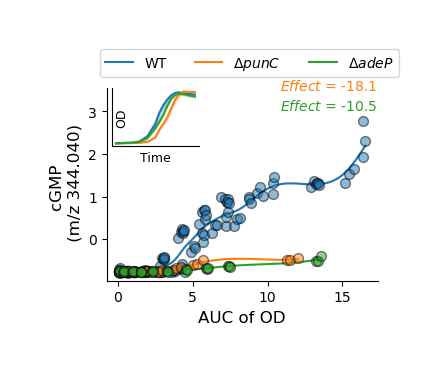

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 2.5), constrained_layout=False, sharex=True)
# axes = axes.flatten()
data_to_plot = [
    ['punC;adeP','cGMP', [1,2]], 
    # ['punC;adeP','Cytidine monophosphate', [1,2]], 
]
xval = 'AUC OD'
for i, (strain_str, metabolite, batch) in enumerate(data_to_plot):
    strains = ['WT'] + strain_str.split(';')
    ionMz = name_to_ionMz[metabolite]

    plot_timecourse_difference(ax, df, batch, strains, ionMz, xval=xval, yval='Median Z-score', ystd='Z-score std')
    # ax.set_title(f'm/z {ionMz[0]:.3f} - {metabolite}', size = 10)
    ax.set_ylabel(f'{metabolite} \n (m/z {ionMz[0]:.3f})', size = 12)
    ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1]*1.2)
    effect1 = np.mean(sel_df.loc[(sel_df.Strain.isin(strains[1:2]))&(sel_df.ionMz.isin(ionMz)), 'Rel. distance'].values)
    ax.text(1, 1.05, f'$Effect$ = {effect1:.1f}', transform=ax.transAxes, size=10, weight='regular', ha = 'right', va = 'top', color = 'C1')
    effect2 = np.mean(sel_df.loc[(sel_df.Strain.isin(strains[2:3]))&(sel_df.ionMz.isin(ionMz)), 'Rel. distance'].values)
    ax.text(1, 0.95, f'$Effect$ = {effect2:.1f}', transform=ax.transAxes, size=10, weight='regular', ha = 'right', va = 'top', color = 'C2')

    # --- OD curve inset ---
    inset_ax = ax.inset_axes([0.02, 0.7, 0.32, 0.3])  # [x0, y0, width, height]
    od_data = od_df.loc[od_df.Strain.isin(strains)&od_df.Batch.isin(batch)]
    l = sns.lineplot(data = od_data, x = 'Hours', y = 'OD', hue = 'Strain', hue_order=strains, ax = inset_ax)
    sns.despine(ax = inset_ax)
    inset_ax.set_xticks([])
    inset_ax.set_yticks([])
    inset_ax.set_ylabel('OD', labelpad = -12, size = 9)
    inset_ax.set_xlabel('Time', size = 9)
    # inset_ax.yaxis.set_label_position('right')
    # inset_ax.set_title('OD', fontsize=8)
    # inset_ax.legend(fontsize=6, loc='upper left', frameon=False)
    # inset_ax.get_legend_handles_labels()
    
    handles, labels = inset_ax.get_legend_handles_labels()
    labels = [f'Δ${lbl}$' if lbl != 'WT' else 'WT' for lbl in labels]
    legend = inset_ax.legend(handles, labels, fontsize=10, loc='lower left', bbox_transform = ax.transAxes,
                            frameon=True, ncol=3, bbox_to_anchor=[-0.05,1.02])
    legend.set_title(None)  # Remove legend title
    

# fig.supylabel('Median Z-score', x=-0.04, y=0.5, rotation=90, size = 12)
if xval == 'Hours':
    ax.set_xlabel('Time [h]', size = 12)
else:
    ax.set_xlabel('AUC of OD', size = 12)
sns.despine()
plt.subplots_adjust(hspace=0.3)
plt.savefig(figure_folder / f'figure_5_punC_adeP_transporterKO_timecourses_{normalization}_norm_lam_{lam}_{xval}.png', dpi=300, bbox_inches='tight')
plt.savefig(figure_folder / f'figure_5_punC_adeP_transporterKO_timecourses_{normalization}_norm_lam_{lam}_{xval}.pdf', dpi=300, bbox_inches='tight')

In [39]:
df.loc[df.Batch==2,'ionMz'].nunique()

246

# Bar charts

In [40]:
all_strains = dis_mz['Strain'].unique()
N_changed_mets = sel_df.groupby('Strain')['Metabolite'].count().reindex(all_strains, fill_value=0).sort_values(ascending=False)
N_changed_mets_neg = sel_df.loc[sel_df['Rel. distance'] < 0].groupby('Strain')['Metabolite'].count().reindex(all_strains, fill_value=0).sort_values(ascending=False)
N_changed_mets_pos = sel_df.loc[sel_df['Rel. distance'] > 0].groupby('Strain')['Metabolite'].count().reindex(all_strains, fill_value=0).sort_values(ascending=False)
met_changes = pd.merge(N_changed_mets_neg, N_changed_mets_pos, left_index=True, right_index=True, how='outer')
met_changes.columns = ['Decrease', 'Increase']
met_changes = met_changes.reset_index()
met_changes.dropna(inplace=True)
met_changes['Total'] = met_changes['Decrease'] + met_changes['Increase']
met_changes.sort_values(by=['Total', 'Strain'], ascending=False, inplace=True)



## Get transporter annotation

In [41]:
transporter_meta_fn = data_folder / 'B_selected_transporters_with_expression_levels.csv'
df_tmeta = pd.read_csv(transporter_meta_fn)

In [42]:
for i, row in df_tmeta.iterrows():
    if row['Type'] in ['Porin/channel']:
        df_tmeta.at[i, 'Type'] = 'Porin / channel'



In [43]:
change_cmap = plt.get_cmap('PiYG')
norm = plt.Normalize(vmin=-10, vmax=10)
icolor = change_cmap(norm(7))
dcolor = change_cmap(norm(-7))

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_37588/4266539580.py:9: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



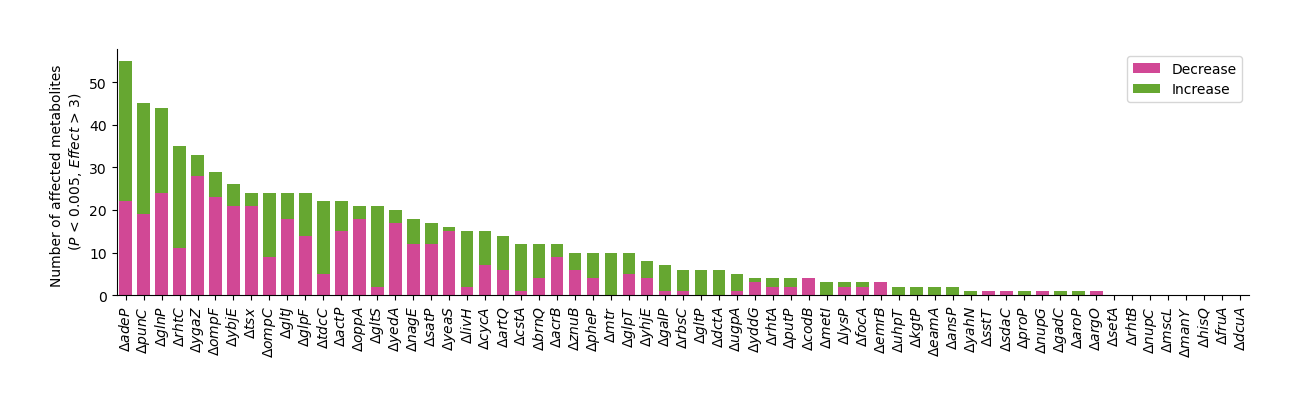

In [44]:
fig, ax = plt.subplots(figsize = (12,3))
bar_width = 0.7  # Adjust this value for wider/narrower bars

ax.bar(met_changes['Strain'], height = met_changes['Decrease'], width=bar_width, label='Decrease', color = dcolor)
ax.bar(met_changes['Strain'], height =  met_changes['Increase'], bottom=met_changes['Decrease'], width=bar_width, label='Increase', color = icolor)
plt.xlim(-0.5, len(met_changes['Strain'])-0.5)
ax.legend()
plt.tight_layout()
ax.set_xticklabels([f'Δ${lbl}$' for lbl in met_changes['Strain']], rotation=90)
plt.ylabel('Number of affected metabolites \n ($P$ < 0.005, $Effect$ > 3)')
# ax.set_ylabel('Number of affected metabolites \n (Effect > %s and p-value < %s)'%(rel_dis_limit, p_val_limit))
sns.despine()
plt.show()


In [45]:
in_out_color = {'Import':'w',
               'Export':'k',
               'Both':'gray'}

In [46]:

# Merge transporter type info into met_changes
met_changest = met_changes.merge(df_tmeta, left_on='Strain', right_on = 'Gene Name', how='left')
unique_types = sorted(met_changest['Type'].unique())
tab10 = plt.get_cmap('tab10')
type_to_color = {t: tab10(i) for i, t in enumerate(unique_types)}

In [47]:
print(met_changest[['Decrease', 'Increase', 'Total']].sum())
met_changest[['Decrease', 'Increase', 'Total']].sum()/dis_df.shape[0]

Decrease    379
Increase    343
Total       722
dtype: int64


Decrease    0.022802
Increase    0.020637
Total       0.043439
dtype: float64

In [48]:
npos = ((dis_mz['Rel. distance'] > 3) & (dis_mz['p-value rel'] < 0.005)).sum()
nn = ((dis_mz['Rel. distance'] < -3) & (dis_mz['p-value rel'] < 0.005)).sum()
print(npos, npos/len(dis_mz), nn, nn/len(dis_mz), len(dis_mz))

343 0.021643109540636044 379 0.023914689550731952 15848


In [49]:
dis_df.Strain.nunique()

66

In [50]:
sel_df.Strain.nunique()

55

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_37588/4131775597.py:9: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



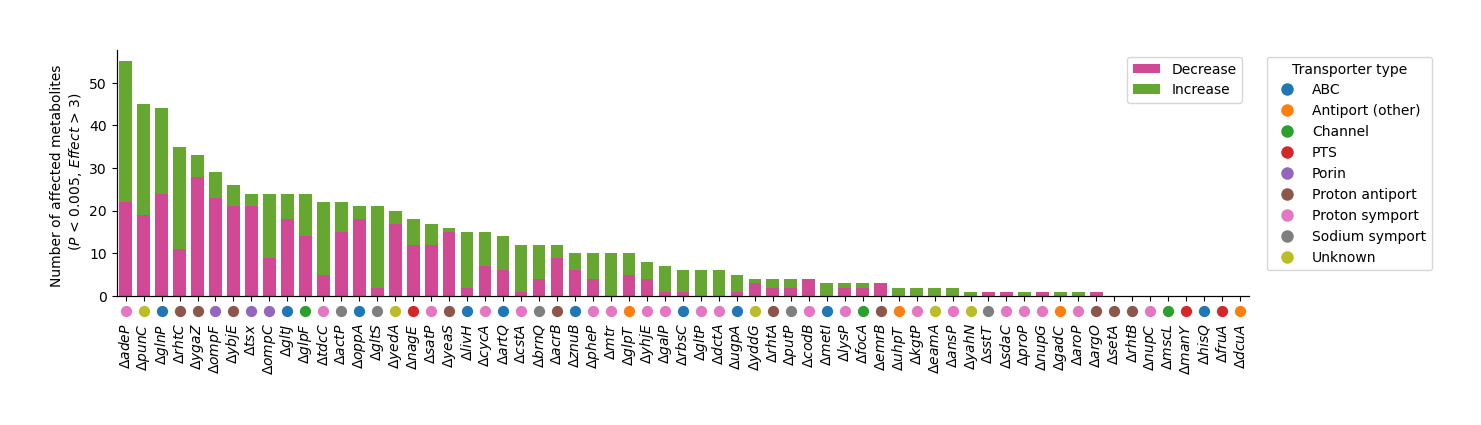

In [51]:


# Plot bars as before
fig, ax = plt.subplots(figsize=(12,3))
bar_width = 0.7
ax.bar(met_changest['Strain'], met_changest['Decrease'], width=bar_width, label='Decrease', color=dcolor)
ax.bar(met_changest['Strain'], met_changest['Increase'], bottom=met_changest['Decrease'], width=bar_width, label='Increase', color=icolor)
plt.xlim(-0.5, len(met_changest['Strain'])-0.5)
ax.legend()
plt.tight_layout()
ax.set_xticklabels([f'Δ${lbl}$' for lbl in met_changest['Strain']], rotation=90, y = -0.07)
plt.ylabel('Number of affected metabolites \n ($P$ < 0.005, $Effect$ > 3)')

# Create a twin x-axis for the dots
ax_dots = ax.twiny()
ax_dots.set_xlim(ax.get_xlim())
ax_dots.set_xticks([])  # Hide ticks

# Place dots just above the tick labels
y_marker = -0.06  # Fraction of axes height above the bottom
for i, (strain, ttype) in enumerate(zip(met_changest['Strain'], met_changest['Type'])):
    ax_dots.scatter(i, y_marker, marker='o', color=type_to_color.get(ttype, 'gray'), s=50, zorder=10, clip_on=False, 
    transform=ax_dots.get_xaxis_transform())
sns.despine()



# Create round legend handles for transporter type
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=type_to_color[t], markersize=10, label=t)
    for t in type_to_color
]


# Add legend to the main axis (ax)
ax_dots.legend(handles=legend_handles, title="Transporter type", bbox_to_anchor=(1.01, 1), loc='upper left')

# # Create a twin x-axis for the dots
# ax_dots2 = ax.twiny()
# ax_dots2.set_xlim(ax.get_xlim())
# ax_dots2.set_xticks([])  # Hide ticks

# # Place dots just above the tick labels
# y_marker = -0.12  # Fraction of axes height above the bottom
# for i, (strain, in_out) in enumerate(zip(met_changest['Strain'], met_changest['Expected direction'])):
#     ax_dots2.scatter(i, y_marker, marker='o', color=in_out_color.get(in_out, 'red'),edgecolor = 'k', s=50, zorder=10, clip_on=False, 
#     transform=ax_dots2.get_xaxis_transform())
# sns.despine()
# # Create legend handles for each transporter type
# legend_handles2 = [
#     Line2D([0], [0], marker='o', color='w',markeredgecolor='k', markerfacecolor=in_out_color[t], markersize=10, label=t)
#     for t in in_out_color
# ]

# Add legend to the main axis (ax)
# ax_dots2.legend(handles=legend_handles2, title="Expected direction", bbox_to_anchor=(0.7, 1), loc='upper left')

plt.savefig(figure_folder / f'figure_5_number_of_changed_metabolites_per_transporter_KO_{normalization}_norm_lam_{lam}.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [52]:
dis_mz.ionMz.nunique()

494

In [53]:
((met_changes['Decrease'] > 0)&(met_changes['Increase'] > 0)).sum()

np.int64(37)

In [54]:
met_changest['Fraction'] = met_changest['Increase'] / met_changest['Total']

In [55]:
met_changest.sort_values(by='Total', ascending=False, inplace=True)

In [56]:
met_changest.groupby('Type').agg({'Total':'max'})

,Total
Type,
ABC,44
Antiport (other),10
Channel,24
PTS,18
Porin,29
Proton antiport,35
Proton symport,55
Sodium symport,22
Unknown,45


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_37588/3048918516.py:10: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



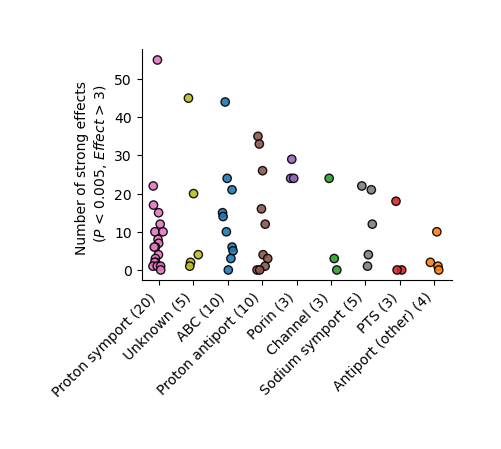

In [57]:
fog, ax = plt.subplots(figsize=(4,3))
plot_order = met_changest.groupby('Type').agg({'Total':'max'}).sort_values(by='Total', ascending=False).index
sns.stripplot(data = met_changest, x='Type', y='Total', jitter=0.2, hue = 'Type', palette=type_to_color, 
            dodge=False, size = 6, edgecolor='k', alpha=0.9, linewidth = 1,
                ax = ax, order=plot_order)
n_dict = met_changest['Type'].value_counts().to_dict()
plt.ylabel(f'Number of strong effects \n ($P$ < 0.005, $Effect$ > {min_effect})')

ticklabels = [f'{t} ({n_dict[t]})' for t in plot_order]
ax.set_xticklabels(ticklabels, rotation=45, ha='right')
plt.xlabel('')
sns.despine()
plt.savefig(figure_folder / f'figure_5_number_of_changed_metabolites_per_transporter_KO_by_type_{normalization}_norm_lam_{lam}.pdf', dpi=300, bbox_inches='tight')

In [58]:
sel_df['Direction'] = (sel_df['Rel. distance'] > 0).map({True: 'Positive', False: 'Negative'})
sel_df['|Effect|'] = np.abs(sel_df['Rel. distance'])

In [59]:
sel_df['Transporter type'] = sel_df['Strain'].map(df_tmeta.set_index('Gene Name')['Type'])

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_37588/757047002.py:22: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



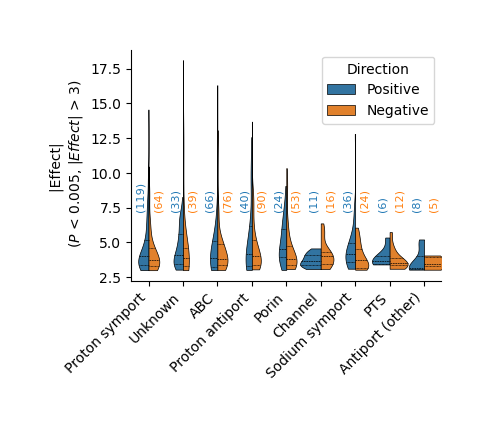

In [60]:
fog, ax = plt.subplots(figsize=(4,3))
# plot_order = sel_df.groupby('Transporter type').agg({'|Effect|':'count'}).sort_values(by='|Effect|', ascending=False).index
# sns.stripplot(data = sel_df, x='Transporter type', y='|Effect|', hue = 'Direction', jitter=True, #palette=type_to_color, 
#             dodge=True, size = 6, edgecolor='gray', alpha=0.3, linewidth = 1,
#                 ax = ax, order=plot_order)
sns.violinplot(data = sel_df, x='Transporter type', y='|Effect|', hue = 'Direction', #palette=type_to_color, 
            dodge=True, split = True, inner='quartile', width = 1.2, cut = 0,
                ax = ax, order=plot_order, edgecolor = 'k', linewidth = 0.5)

# sns.boxplot(data = sel_df, x='Transporter type', y='|Effect|', hue = 'Direction', #palette=type_to_color, 
#             dodge=True, fliersize=0, linewidth = 1.4, boxprops={'facecolor':'none'},  
#                 ax = ax, order=plot_order, zorder = 0, legend = False)
plt.ylabel(f'|Effect| \n ($P$ < 0.005, |$Effect$| > {min_effect})')

n_dict = sel_df[['Transporter type', 'Direction']].value_counts().to_dict()
for ttype in plot_order:
    for i, direction in enumerate(['Positive', 'Negative']):
        count = n_dict.get((ttype, direction), 0)
        xpos = list(plot_order).index(ttype) + (-0.25 if direction == 'Positive' else 0.25)+0.03
        ax.text(xpos, sel_df['|Effect|'].max()*0.4, f'({count})', ha='center', va='bottom', size=8, rotation = 90, c = f'C{i}')

ax.set_xticklabels(plt.gca().get_xticklabels(), rotation=45, ha='right')
plt.xlabel('')
sns.despine()
plt.savefig(figure_folder / f'figure_5_effect_distribution_per_transporter_KO_by_type_{normalization}_norm_lam_{lam}.pdf', dpi=300, bbox_inches='tight')

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_37588/1059474829.py:34: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



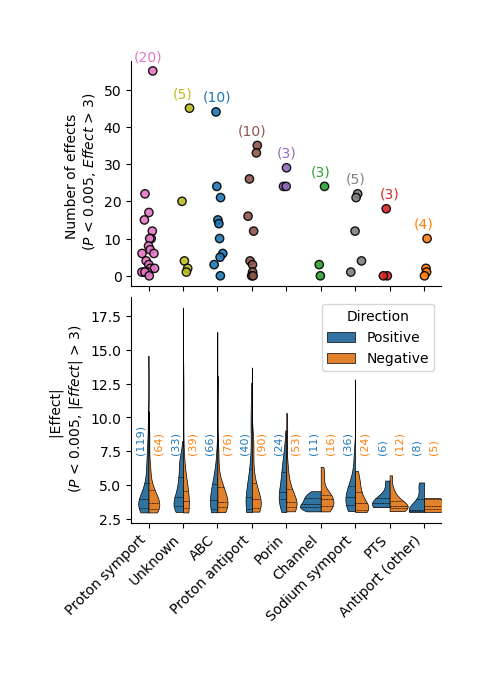

In [61]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4,6), sharex=True)

plot_order = met_changest.groupby('Type').agg({'Total':'max'}).sort_values(by='Total', ascending=False).index
sns.stripplot(data = met_changest, x='Type', y='Total', jitter=0.2, hue = 'Type', palette=type_to_color, 
            dodge=False, size = 6, edgecolor='k', alpha=0.9, linewidth = 1,
                ax = ax1, order=plot_order)
n_dict = met_changest['Type'].value_counts().to_dict()
ax1.set_ylabel(f'Number of effects \n ($P$ < 0.005, $Effect$ > {min_effect})')

mmax = met_changest.groupby('Type').agg({'Total':'max'}).to_dict()['Total']
for i, t in enumerate(plot_order):
    ax1.text(i, mmax[t]+2, f'({n_dict[t]})', ha='center', va='bottom', size=10, 
            rotation = 0, c = type_to_color[t])

# ticklabels = [f'{t} ({n_dict[t]})' for t in plot_order]
# ax.set_xticklabels(ticklabels, rotation=45, ha='right')

sns.violinplot(data = sel_df, x='Transporter type', y='|Effect|', hue = 'Direction', #palette=type_to_color, 
            dodge=True, split = True, inner='quartile', width = 1.2, cut = 0,
                ax = ax2, order=plot_order, edgecolor = 'k', linewidth = 0.5)

# sns.boxplot(data = sel_df, x='Transporter type', y='|Effect|', hue = 'Direction', #palette=type_to_color, 
#             dodge=True, fliersize=0, linewidth = 1.4, boxprops={'facecolor':'none'},  
#                 ax = ax, order=plot_order, zorder = 0, legend = False)
ax2.set_ylabel(f'|Effect| \n ($P$ < 0.005, |$Effect$| > {min_effect})')

n_dict = sel_df[['Transporter type', 'Direction']].value_counts().to_dict()
for ttype in plot_order:
    for i, direction in enumerate(['Positive', 'Negative']):
        count = n_dict.get((ttype, direction), 0)
        xpos = list(plot_order).index(ttype) + (-0.25 if direction == 'Positive' else 0.25)+0.03
        ax2.text(xpos, sel_df['|Effect|'].max()*0.4, f'({count})', ha='center', va='bottom', size=8, rotation = 90, c = f'C{i}')
plt.subplots_adjust(hspace=0.05)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
sns.despine()
ax2.set_xlabel('')
plt.savefig(figure_folder / f'figure_5_effect_distribution_and_max_per_transporter_KO_by_type_{normalization}_norm_lam_{lam}.pdf', dpi=300, bbox_inches='tight')

In [62]:
# Drop NaNs if present
anova_data = sel_df.dropna(subset=['|Effect|', 'Transporter type'])

# Prepare groups for ANOVA
groups = [group['|Effect|'].values for name, group in anova_data.groupby('Transporter type')]

print(len(groups))
# Perform one-way ANOVA
f_stat, p_value = st.f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.3f}, p-value: {p_value:.3g}")

9
ANOVA F-statistic: 1.618, p-value: 0.116


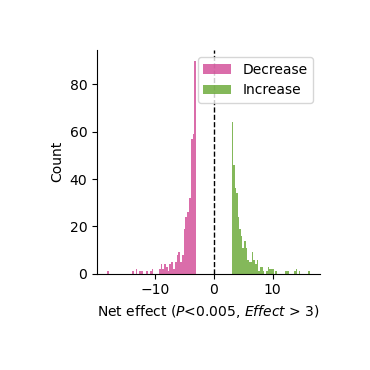

In [63]:
plt.figure(figsize=(3, 3))
data = sel_df['Rel. distance']

# plt.hist(dis_mz['Rel. distance'], bins=100, alpha=0.3, color='grey', label='All')
plt.hist(data[data < 0], bins=50, alpha=0.8, color=dcolor, label='Decrease')
plt.hist(data[data > 0], bins=50, alpha=0.8, color=icolor, label='Increase')

plt.axvline(0, color='k', linestyle='--', lw=1)
plt.xlabel('Net effect ($P$<%s, $Effect$ > %s)'%(max_pval, min_effect))
plt.ylabel('Count')
plt.legend()
# plt.yscale('log')
# plt.title('Overlay of Negative and Positive Rel. distance')
# plt.title('Distribution of net effects ($P$<%s, $Effect$ > %s)'%(max_pval, min_effect))
plt.tight_layout()
sns.despine()
plt.savefig(figure_folder / f'figure_5_distribution_of_net_effects_transporter_KO_{normalization}_norm_lam_{lam}.pdf', dpi=300, bbox_inches='tight')
plt.show()

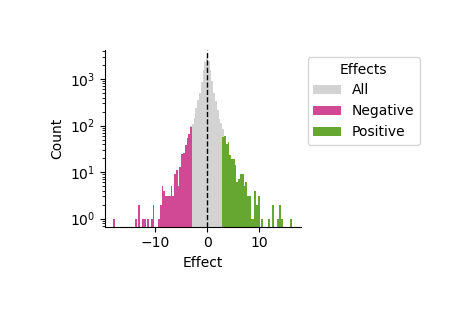

In [64]:
plt.figure(figsize=(4, 2.5))
data = sel_df['Rel. distance']

l = plt.hist(dis_mz['Rel. distance'], bins=100, alpha=1, color='lightgray', label='All', lw = 0)#histtype='step', zorder = 10
# plt.hist(dis_mz.loc[dis_mz['p-value rel']<max_pval, 'Rel. distance'], bins=l[1], alpha=1, color='darkgrey', label='Significant ($P$<%s)'%max_pval, lw = 0)

# plt.hist(dis_mz['Rel. distance'], bins=100, alpha=0.3, color='grey', label='All')
plt.hist(data[data < 0], bins=l[1], alpha=1, color=dcolor, label=f'Negative') #($Effect$ < -{min_effect}, $P$ < {max_pval})
plt.hist(data[data > 0], bins=l[1], alpha=1, color=icolor, label=f'Positive')

plt.axvline(0, color='k', linestyle='--', lw=1)
plt.xlabel('Effect')
plt.ylabel('Count')
plt.legend(loc = 'upper left', bbox_to_anchor=(1,1), ncol = 1, title = 'Effects')
plt.yscale('log')
# plt.title('Overlay of Negative and Positive Rel. distance')
# plt.title('Distribution of net effects ($P$<%s, $Effect$ > %s)'%(max_pval, min_effect))
plt.tight_layout()
sns.despine()
plt.savefig(figure_folder / f'figure_5_distribution_of_net_effects_transporter_KO_{normalization}_norm_lam_{lam}.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 

## Metabolite centric

In [65]:
move_to_other = ['Benzenoids', 'Other organic acids', 'Phenylpropanoids and polyketides', 'Organic nitrogen compounds']
for i, row in df_ionMz.iterrows():
    clses  = row['Classes'].split(';')
    new_classes = list(set(['Other' if c in move_to_other else c for c in clses]))
    df_ionMz.at[i, 'Classes'] = ';'.join(new_classes)


In [66]:
df_ionMz_nodup = df_ionMz.drop_duplicates(subset=['Metabolite'], keep='first')

In [67]:
all_metabolites = dis_mz['Metabolite'].unique()
# N_changed_strains = sel_df.groupby('ionMz')['Strain'].count().reindex(all_metabolites, fill_value=0).sort_values(ascending=False)
N_changed_strains_neg = sel_df.loc[sel_df['Rel. distance'] < 0].groupby('Metabolite')['Strain'].count().reindex(all_metabolites, fill_value=0).sort_values(ascending=False)
N_changed_strains_pos = sel_df.loc[sel_df['Rel. distance'] > 0].groupby('Metabolite')['Strain'].count().reindex(all_metabolites, fill_value=0).sort_values(ascending=False)
strain_changes = pd.merge(N_changed_strains_neg, N_changed_strains_pos, left_index=True, right_index=True, how='outer')
strain_changes.columns = ['Decrease', 'Increase']
strain_changes = strain_changes.reset_index()
strain_changes.dropna(inplace=True)
strain_changes['Total'] = strain_changes['Decrease'] + strain_changes['Increase']
strain_changes.sort_values(by=['Total'], ascending=[True], inplace=True)
strain_changes = strain_changes[strain_changes['Total'] > 0]

In [68]:
len(all_metabolites)

333

In [69]:
len(set(all_metabolites))


333

In [70]:
len(strain_changes)

122

In [71]:
((strain_changes['Decrease'] > 0)&(strain_changes['Increase'] > 0)).sum()

np.int64(57)

In [72]:
strain_changes = pd.merge(left = strain_changes, right = df_ionMz_nodup, on = 'Metabolite', how='left')

In [73]:
all_classes = []
for cstring in df_ionMz['Classes']:
    if pd.isna(cstring):
        continue
    classes = cstring.split(';')
    all_classes += classes
all_classes = list(set(all_classes))


In [74]:
class_to_color = {cls: plt.cm.tab10(i) for i, cls in enumerate(sorted(list(set(all_classes))))}

In [75]:
len(all_classes)

9

In [76]:
strain_changes.Classification.value_counts()

Classification
Amino acids                     37
Mixed                           19
Other                           13
Unknown                         12
Organoheterocyclic compounds    10
Keto / hydroxy acids             8
Nucleotides / nucleosides        8
Organic oxygen compounds         6
Lipid-like molecules             6
Carboxylic acids                 3
Name: count, dtype: int64

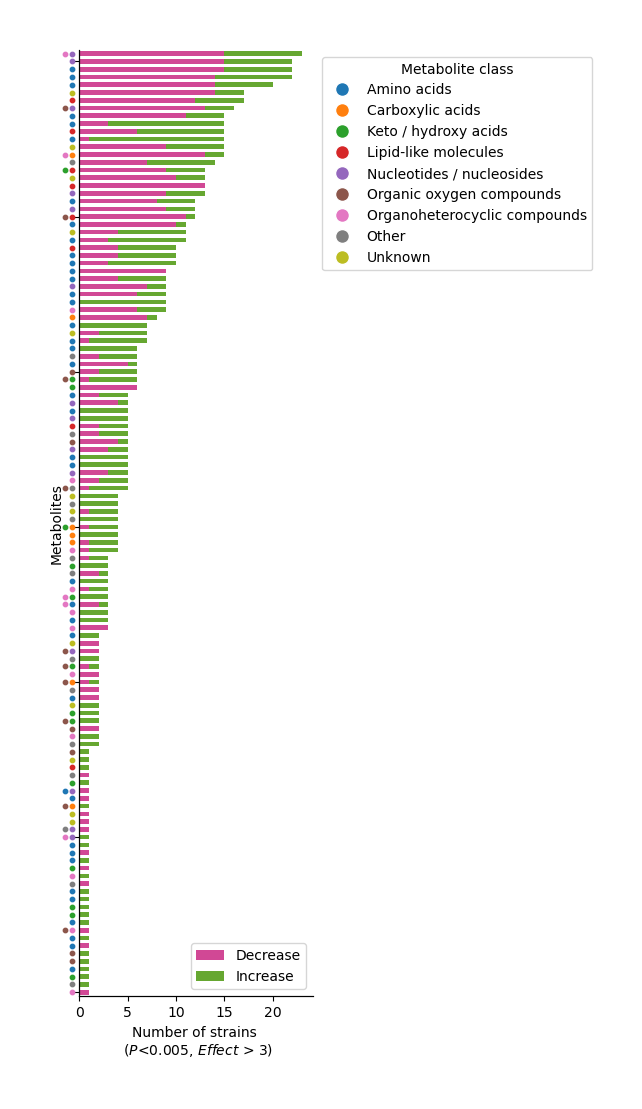

In [77]:
fig, ax = plt.subplots(figsize = (3,10))
bar_width = 0.6  # Adjust this value for wider/narrower bars

ax.barh(strain_changes.index, width = strain_changes['Total'], height=bar_width, label='Decrease', color = dcolor, alpha = 1)
ax.barh(strain_changes.index, width =  strain_changes['Increase'], left=strain_changes['Decrease'], height=bar_width, label='Increase', color = icolor, alpha = 1)
plt.ylim(-0.5, len(strain_changes['Metabolite'])-0.5)
ax.legend()
plt.tight_layout()
# ax.set_xticklabels([lbl for lbl in strain_changes['Metabolite']], rotation=90, size = 6)
ax.set_yticklabels([])
plt.xlabel('Number of strains \n ($P$<%s, $Effect$ > %s)'%(max_pval, min_effect))
plt.ylabel('Metabolites')
# ax.set_ylabel('Number of affected metabolites \n (Effect > %s and p-value < %s)'%(rel_dis_limit, p_val_limit))
sns.despine()


# Create a twin x-axis for the dots
ax_dots = ax.twinx()
ax_dots.set_ylim(ax.get_ylim())
ax_dots.set_yticks([])  # Hide ticks

# Place dots just above the tick labels
x_marker = -0.03  # Fraction of axes height above the bottom
for i, row in strain_changes.iterrows():
    # ax_dots.plot([x_marker, -0.01], [i,i], color=class_to_color[row['Classification']], lw = 3, zorder=10, clip_on=False, 
    # transform=ax_dots.get_yaxis_transform())
    met_classes = row['Classes'].split(';')
    for j, met_class in enumerate(met_classes):
        ax_dots.scatter(x_marker - j*0.03, i, color=class_to_color[met_class], s= 10, zorder=10, clip_on=False, 
        transform=ax_dots.get_yaxis_transform())
    # ax_dots.scatter(x_marker, i, color=class_to_color[row['Classification']], s= 10, zorder=10, clip_on=False, 
    # transform=ax_dots.get_yaxis_transform())
sns.despine()

# for i, (strain, ttype) in enumerate(zip(met_changest['Strain'], met_changest['Type'])):
#     ax_dots.scatter(i, y_marker, marker='o', color=type_to_color.get(ttype, 'gray'), s=50, zorder=10, clip_on=False, 
#     transform=ax_dots.get_xaxis_transform())
# sns.despine()


# Create round legend handles for transporter type
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=class_to_color[t], markersize=10, label=t)
    for t in class_to_color
]
# end to the main axis (ax)
ax_dots.legend(handles=legend_handles, title="Metabolite class", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.savefig(figure_folder / f'figure_5_number_of_changed_strains_per_metabolite_KO_{normalization}_norm_lam_{lam}.pdf', dpi=300, bbox_inches='tight')

plt.show()

In [78]:
strain_changes.head(30)

,Metabolite,Decrease,Increase,Total,ionMz,KEGG,All metabolite names,Alt. annotations,Classes,Classification
0,Riboflavin,1,0,1,375.1310,C00255,Riboflavin,NaN,Organoheterocyclic compounds,Organoheterocyclic compounds
1,Aminoacetaldehyde,0,1,1,58.0295,C06735,Aminoacetaldehyde,NaN,Other,Other
2,4-Methyl-2-oxopentanoate,0,1,1,129.0560,C00233;C00671;C03465,2-Keto-3-methyl-valerate / 4-Methyl-2-oxopenta...,2-Keto-3-methyl-valerate / Ketoleucine,Keto / hydroxy acids,Keto / hydroxy acids
3,Ornithine,0,1,1,131.0828,C00077;C01602,Ornithine,NaN,Amino acids,Amino acids
4,Phosphoribosyl pyrophosphate,0,1,1,388.9444,C00119,Phosphoribosyl pyrophosphate,NaN,Organic oxygen compounds,Organic oxygen compounds
5,3-Dehydro-gulonate 6-phosphate,0,1,1,273.0016,C05385;C14899,3-Dehydro-gulonate 6-phosphate / Glucuronate 1...,Glucuronate 1-phosphate,Organic oxygen compounds,Organic oxygen compounds
6,Aspartate semialdehyde,1,0,1,116.0356,C00441;C03508;C20250,(Z)-2-Methyl-peroxyaminoacrylate / 2-Amino-3-o...,(Z)-2-Methyl-peroxyaminoacrylate / 2-Amino-3-o...,Amino acids,Amino acids
7,Phenylalanine,0,1,1,164.0717,C00079;C02265,Phenylalanine,NaN,Amino acids,Amino acids
8,Pentose,1,0,1,149.0455,C00121;C00181;C00216;C00259;C00309;C00310;C003...,Pentose / Lyxose / Ribose / Ribulose / Threo-2...,Lyxose / Ribose / Ribulose / Threo-2-pentulose...,Organoheterocyclic compounds;Organic oxygen co...,Mixed
9,Glutamine,0,1,1,145.0621,C00064;C00819;C05100,Glutamine / Ureidoisobutyric acid,Ureidoisobutyric acid,Amino acids,Amino acids


In [79]:
print(len(strain_changes))
print(((strain_changes['Decrease']>0)&(strain_changes['Increase']>0)).sum())

122
57


In [80]:
class_to_color['Mixed'] = plt.cm.tab10(9)

In [81]:
strain_changes['Classification'].value_counts()

Classification
Amino acids                     37
Mixed                           19
Other                           13
Unknown                         12
Organoheterocyclic compounds    10
Keto / hydroxy acids             8
Nucleotides / nucleosides        8
Organic oxygen compounds         6
Lipid-like molecules             6
Carboxylic acids                 3
Name: count, dtype: int64

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_37588/2835973579.py:12: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



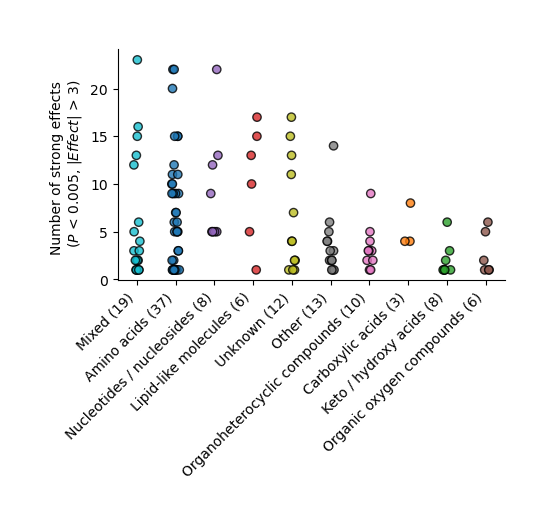

In [82]:
fig, ax = plt.subplots(figsize = (5,3))
# plot_order = strain_changes['Classification'].value_counts().index.to_list()
plot_order = strain_changes.groupby('Classification').agg({'Total':'max'}).sort_values(by='Total', ascending=False).index
ax = sns.stripplot(data = strain_changes, x = 'Classification', y = 'Total', hue = 'Classification', palette=class_to_color, dodge=False,
             size = 6, edgecolor='k', alpha=0.8, linewidth = 1, ax = ax, jitter = 0.1, order=plot_order)#, hue_order=plot_order)
            
# sns.boxplot(data = strain_changes, y = 'Classification', x = 'Total', 
#                 boxprops={'facecolor':'none'}, showfliers=False)
n_dict = strain_changes['Classification'].value_counts().to_dict()
xticklabels = [f'{t.get_text()} ({n_dict[t.get_text()]})' for t in ax.get_xticklabels()]

ax.set_xticklabels(xticklabels, rotation=45, ha='right')
plt.xlabel('')
plt.ylabel('Number of strong effects \n ($P$ < 0.005, |$Effect$| > 3)')
sns.despine()
plt.savefig(figure_folder / f'figure_5_number_of_changed_strains_per_metabolite_class_KO_{normalization}_norm_lam_{lam}.pdf', dpi=300, bbox_inches='tight')


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Mixed'),
  Text(1, 0, 'Amino acids'),
  Text(2, 0, 'Nucleotides / nucleosides'),
  Text(3, 0, 'Lipid-like molecules'),
  Text(4, 0, 'Unknown'),
  Text(5, 0, 'Other'),
  Text(6, 0, 'Organoheterocyclic compounds'),
  Text(7, 0, 'Carboxylic acids'),
  Text(8, 0, 'Keto / hydroxy acids'),
  Text(9, 0, 'Organic oxygen compounds')])

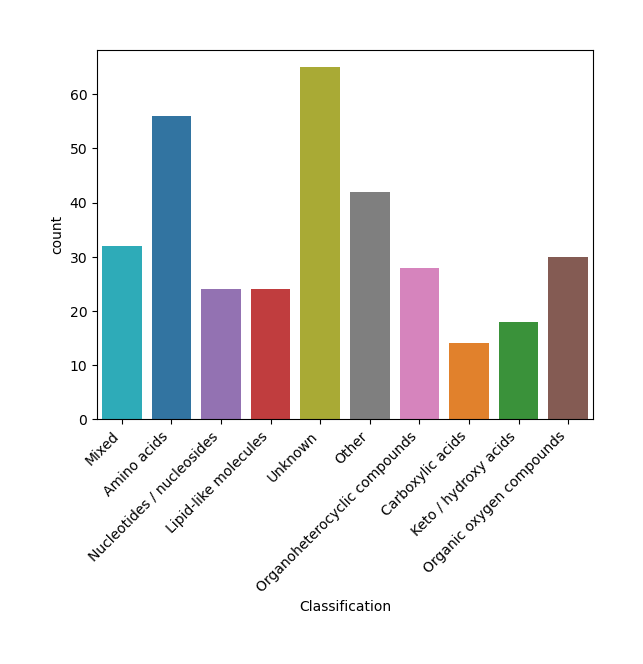

In [83]:
temp_df = df_ionMz_nodup['Classification'].value_counts().reset_index()
sns.barplot(data = temp_df, x = 'Classification', y = 'count', hue = 'Classification', palette=class_to_color, order = plot_order)
plt.xticks(rotation=45, ha='right')

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_37588/3602175097.py:19: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



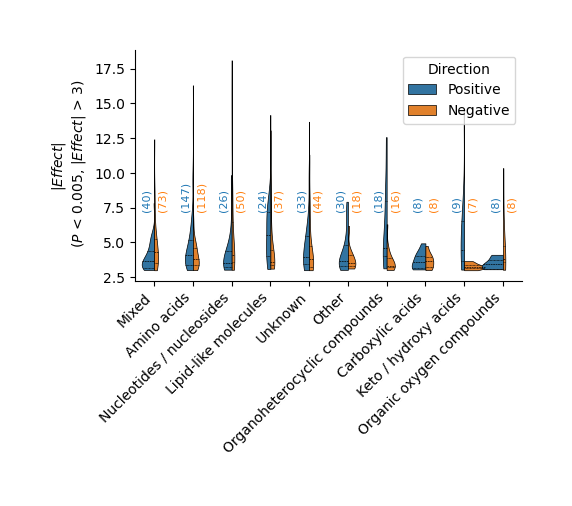

In [84]:
fig, ax = plt.subplots(figsize = (5,3))
# plot_order = strain_changes['Classification'].value_counts().index.to_list()
# ax = sns.stripplot(data = sel_df, x = 'Classification', y = '|Effect|', hue = 'Direction',  dodge=True,
#              size = 6, edgecolor='k', alpha=0.8, linewidth = 1, ax = ax, jitter = 0.1)#, order=plot_order, hue_order=plot_order)
sns.violinplot(data = sel_df, x='Classification', y='|Effect|', hue = 'Direction', #palette=type_to_color, 
            dodge=True, split = True, inner='quartile', width = 1.1, cut = 0,
                ax = ax, edgecolor = 'k', linewidth = 0.5, order = plot_order)
n_dict = sel_df[['Classification', 'Direction']].value_counts().to_dict()
for met_class in plot_order:
    for i, direction in enumerate(['Positive', 'Negative']):
        count = n_dict.get((met_class, direction), 0)
        xpos = list(plot_order).index(met_class) + (-0.21 if direction == 'Positive' else 0.21)+0.01
        ax.text(xpos, sel_df['|Effect|'].max()*0.4, f'({count})', ha='center', va='bottom', size=8, rotation = 90, c = f'C{i}')
# sns.boxplot(data = strain_changes, y = 'Classification', x = 'Total', 
#                 boxprops={'facecolor':'none'}, showfliers=False)
# n_dict = strain_changes['Classification'].value_counts().to_dict()
# xticklabels = [f'{t.get_text()} ({n_dict[t.get_text()]})' for t in ax.get_xticklabels()]
sns.move_legend(ax, "upper right", bbox_to_anchor=(1, 1), frameon=True)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.xlabel('')
plt.ylabel('|$Effect$| \n ($P$ < 0.005, |$Effect$| > 3)')
sns.despine()
plt.savefig(figure_folder / f'figure_5_number_of_effect_distribution_per_metabolite_class_KO_{normalization}_norm_lam_{lam}.pdf', dpi=300, bbox_inches='tight')


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_37588/4124195714.py:34: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



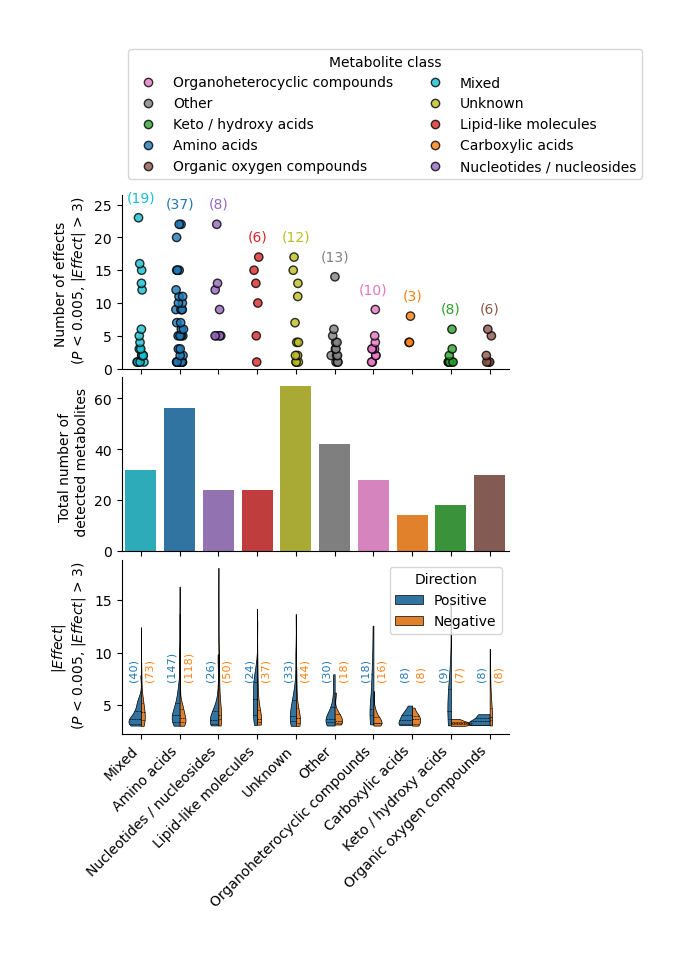

In [85]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize = (5,7), sharex=True)
plot_order = strain_changes.groupby('Classification').agg({'Total':'max'}).sort_values(by='Total', ascending=False).index
sns.stripplot(data = strain_changes, x = 'Classification', y = 'Total', hue = 'Classification', palette=class_to_color, dodge=False,
             size = 6, edgecolor='k', alpha=0.8, linewidth = 1, ax = ax1, jitter = 0.1, order=plot_order, legend = True)#, hue_order=plot_order)
            
# sns.boxplot(data = strain_changes, y = 'Classification', x = 'Total', 
#                 boxprops={'facecolor':'none'}, showfliers=False)
n_dict = strain_changes['Classification'].value_counts().to_dict()
smax = strain_changes.groupby('Classification').agg({'Total':'max'}).to_dict()['Total']
for i, c in enumerate(plot_order):
    n = n_dict[c]
    ax1.text(i, smax[c]+2, f'({n})', ha='center', va='bottom', size=10, rotation = 0, c = class_to_color[c])
ax1.set_ylim(0, ax1.get_ylim()[1]*1.1)
# plot_order = strain_changes['Classification'].value_counts().index.to_list()
# ax = sns.stripplot(data = sel_df, x = 'Classification', y = '|Effect|', hue = 'Direction',  dodge=True,
#              size = 6, edgecolor='k', alpha=0.8, linewidth = 1, ax = ax, jitter = 0.1)#, order=plot_order, hue_order=plot_order)

sns.barplot(data = temp_df, x = 'Classification', y = 'count', hue = 'Classification', palette=class_to_color, order = plot_order, ax = ax2)
sns.violinplot(data = sel_df, x='Classification', y='|Effect|', hue = 'Direction', #palette=type_to_color, 
            dodge=True, split = True, inner='quartile', width = 1.1, cut = 0,
                ax = ax3, edgecolor = 'k', linewidth = 0.5, order = plot_order)
n_dict = sel_df[['Classification', 'Direction']].value_counts().to_dict()
for met_class in plot_order:
    for i, direction in enumerate(['Positive', 'Negative']):
        count = n_dict.get((met_class, direction), 0)
        xpos = list(plot_order).index(met_class) + (-0.21 if direction == 'Positive' else 0.21)+0.01
        ax3.text(xpos, sel_df['|Effect|'].max()*0.4, f'({count})', ha='center', va='bottom', size=8, rotation = 90, c = f'C{i}')
# sns.boxplot(data = strain_changes, y = 'Classification', x = 'Total', 
#                 boxprops={'facecolor':'none'}, showfliers=False)
# n_dict = strain_changes['Classification'].value_counts().to_dict()
# xticklabels = [f'{t.get_text()} ({n_dict[t.get_text()]})' for t in ax.get_xticklabels()]
sns.move_legend(ax1, "lower left", bbox_to_anchor=(0, 1.05), ncol = 2, frameon=True, title = 'Metabolite class')
sns.move_legend(ax3, "upper right", bbox_to_anchor=(1, 1), frameon=True)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')
plt.xlabel('')
ax1.set_ylabel('Number of effects \n ($P$ < 0.005, |$Effect$| > 3)')
ax2.set_ylabel('Total number of \n detected metabolites')
ax3.set_ylabel('|$Effect$| \n ($P$ < 0.005, |$Effect$| > 3)')
sns.despine()
plt.subplots_adjust(hspace=0.05)
plt.savefig(figure_folder / f'figure_5_number_of_effect_and_effect_distribution_per_metabolite_class_KO_{normalization}_norm_lam_{lam}.pdf', dpi=300, bbox_inches='tight')


In [86]:
# Drop NaNs if present
anova_data = sel_df.dropna(subset=['|Effect|', 'Classification'])

# Prepare groups for ANOVA
groups = [group['|Effect|'].values for name, group in anova_data.groupby('Classification')]

print(len(groups))
# Perform one-way ANOVA
f_stat, p_value = st.f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.3f}, p-value: {p_value:.3g}")

10
ANOVA F-statistic: 1.573, p-value: 0.119


# Chord diagram


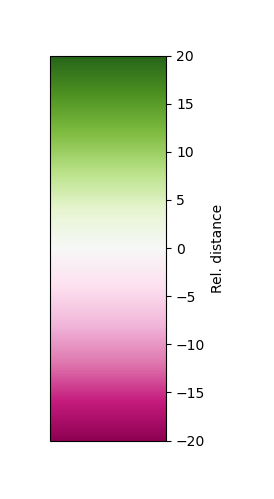

In [87]:
# Define the colors: C2 for negative, white for zero, C4 for positive
# cmap = mpl.colors.LinearSegmentedColormap.from_list(
#     "custom_diverging", ["C4", "C2"]
# )


import matplotlib as mpl
cmap = plt.get_cmap('PiYG')

# Normalize so that 0 is the center
vmin = -20#sel_df['Rel. distance'].min()
vmax = +20#sel_df['Rel. distance'].max()
norm = plt.cm.colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
# Example: create a colorbar only
fig, ax = plt.subplots(figsize=(1.5, 5))
cb = mpl.colorbar.ColorbarBase(
    ax,
    cmap=cmap,
    norm=norm,
    orientation='vertical',
    label='Rel. distance'
)
plt.savefig(figure_folder / f'figure_5_colorbar_rel_distance_transporter_KO_{normalization}_norm_lam_{lam}.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [88]:
ionMz_to_name = {}
for name, ionMz_list in name_to_ionMz.items():
    for ionMz in ionMz_list:
        ionMz_to_name[ionMz] = name 

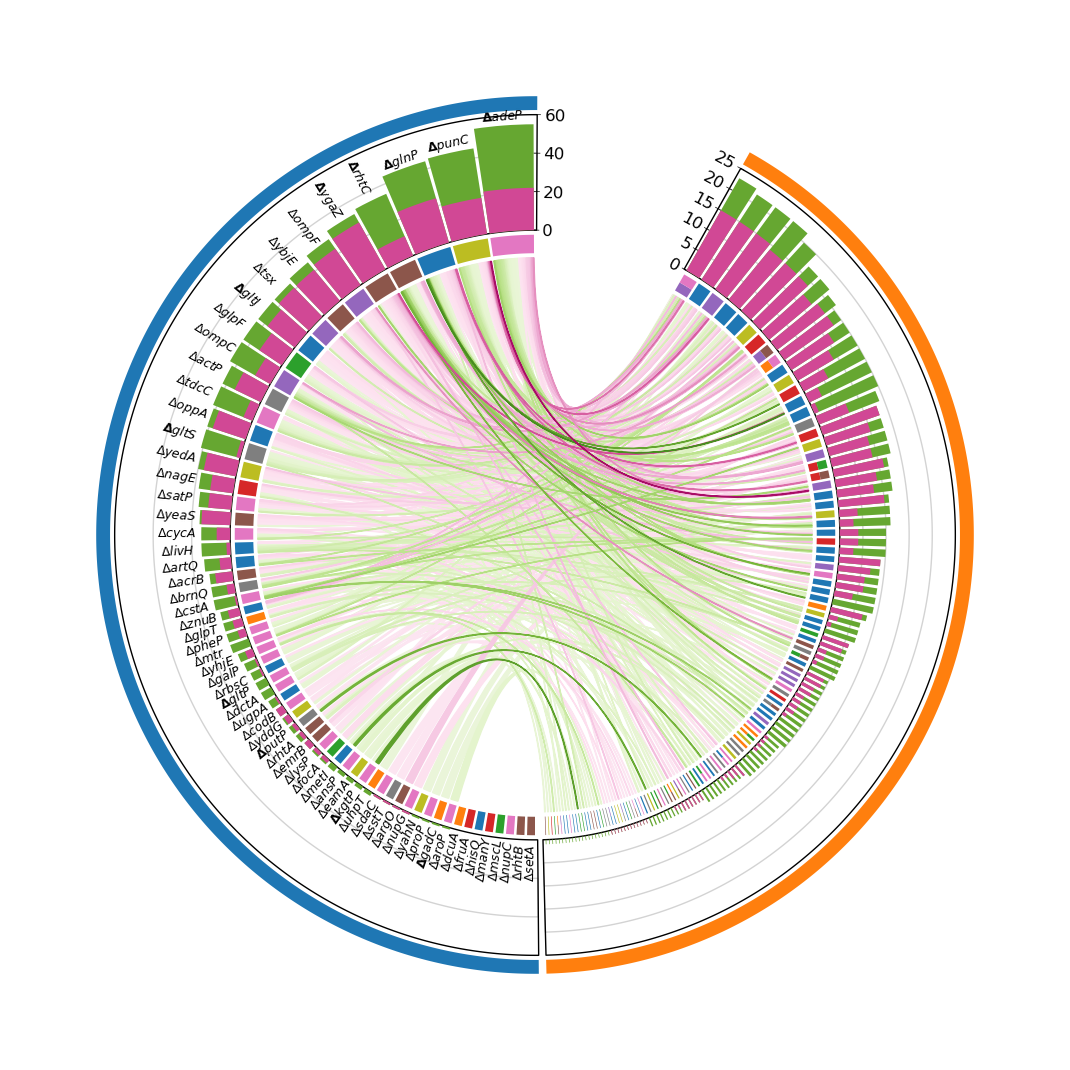

In [89]:
sp = 10#Space padding
r1 = 51+sp
r2 = 55+sp
r3 = 81+sp
total = strain_changes.Total.sum()+met_changest.Total.sum()+len(met_changest)+len(strain_changes)


met_changest.sort_values(by=['Total', 'Decrease'], inplace=True, ascending=True)
met_changest.reset_index(inplace=True, drop=True)
strain_changes.sort_values(by=['Total', 'Decrease'], inplace=True, ascending=False)
strain_changes.reset_index(inplace=True, drop=True)

strain_to_total = met_changest.set_index('Strain')['Total'].to_dict()
strain_to_decrease = met_changest.set_index('Strain')['Decrease'].to_dict()
strain_to_type = met_changest.set_index('Strain')['Type'].to_dict()

met_to_total = strain_changes.set_index('Metabolite')['Total'].to_dict()
met_to_decrease = strain_changes.set_index('Metabolite')['Decrease'].to_dict()
met_to_class = strain_changes.set_index('Metabolite')['Classes'].to_dict()


min_width_strain = 10
def round_up_to_5(x):
    return int(np.ceil(x / 5.0)) * 5

met_size_scaling = 0.8
met_sectors = {row['Metabolite']: max(row['Total'], 1)*360*met_size_scaling/total for i, row in strain_changes.iterrows()}
strain_sectors = {row['Strain']: max(row['Total'], min_width_strain)*360/total for i, row in met_changest.iterrows()}
strains = met_changest.Strain.unique().tolist()
# # sectors = OrderedDict()
sectors = {**strain_sectors, **met_sectors}
spaces = list(np.ones(len(sectors))*0.5)
spaces[len(strains)-1] = 30
spaces[-1] = 2
circos = Circos(sectors=sectors,
                space = spaces,
                start = -180,
                end = 180,
                # endspace = 30
                # sector2clockwise = {sector:False for sector in sectors.keys()}
            )

sector_name_to_index = {sector.name: i for i, sector in enumerate(circos.sectors)}

strain_bar_max = 60#round_up_to_5(max(strain_to_total.values()))
met_bar_max = round_up_to_5(max(met_to_total.values()))
for sector in circos.sectors:
    # Plot sector axis & name text
    # sector.axis(fc="none", ls="dashdot", lw=2, ec="black", alpha=0.5)
    # sector.text(f"Sector: {sector.name}={sector.size}", size=15)
    # print(sector.name, sector.size)
    btrack = sector.add_track((r2+1, r3))
    btrack.axis(ec = 'k', lw=0)
    # btrack.grid(5)

    if sector.name in strains:
        btrack.bar(x = [sector._start], height = [strain_to_total[sector.name]], vmax = strain_bar_max, width = sector.size, color=icolor, align='edge')#edgecolor='k')
        btrack.bar(x = [sector._start], height = [strain_to_decrease[sector.name]], vmax = strain_bar_max, width = sector.size, color=dcolor, align='edge')#, edgecolor='')
        sector.rect(r_lim=(r1, r2), fc=type_to_color[strain_to_type[sector.name]], ec=None, lw=0)

        if sector.name == 'adeP':
            ytickss = np.arange(0, strain_bar_max+1, 20, dtype=int)
            btrack.yticks(ytickss,labels = [str(x) for x in ytickss], side = 'right', label_size=12)
    else:
        btrack.bar(x = [sector._start], height = [met_to_total[sector.name]], vmax = met_bar_max, width = sector.size, color=icolor, align='edge')#edgecolor='k')
        btrack.bar(x = [sector._start], height = [met_to_decrease[sector.name]], vmax = met_bar_max, width = sector.size, color=dcolor, align='edge')#, edgecolor='')
        met_classes = met_to_class[sector.name].split(';')
        # mname = ionMz_to_name[sector.name]
        # sector.text(f"{mname}", size=8, r = r2+2, rotation = -np.mean(sector.deg_lim)-90, adjust_rotation=False, va='center', ha='center')
        if len(met_classes) == 1:
            sector.rect(r_lim=(r1, r2), fc=class_to_color[met_classes[0]], ec=None, lw=0)
        elif len(met_classes) == 2:
            sector.rect(r_lim=(r1, (r1+r2)/2), fc=class_to_color[met_classes[0]], ec=None, lw=0)
            sector.rect(r_lim=((r1+r2)/2, r2), fc=class_to_color[met_classes[1]], ec=None, lw=0)
        elif len(met_classes) >=3:
            sector.rect(r_lim=(r1, r1+(r2-r1)/3), fc=class_to_color[met_classes[0]], ec=None, lw=0)
            sector.rect(r_lim=(r1+(r2-r1)/3, r1+2*(r2-r1)/3), fc=class_to_color[met_classes[1]], ec=None, lw=0) 
            sector.rect(r_lim=(r1+2*(r2-r1)/3, r2), fc=class_to_color[met_classes[2]], ec=None, lw=0)
        
        if sector.name == strain_changes.iloc[0]['Metabolite']:
            yticksm = np.arange(0, met_bar_max+1, 5, dtype=int)
            btrack.yticks(yticksm,labels = [str(x) for x in yticksm], side = 'left', label_size = 12)
        # btrack.bar(x = [0], height = [
    # else:
        # print(sector.size)
first_strain_sector = circos.sectors[0]
last_strain_sector = circos.sectors[len(strains)-1]
first_met_sector = circos.sectors[len(strains)]
last_met_sector = circos.sectors[-1]


e = 0.5
circos.rect(r_lim=(82+sp, 85+sp), fc="C0", ec="black",deg_lim=(first_strain_sector.deg_lim[0]-e,last_strain_sector.deg_lim[1]+e))
circos.rect(r_lim=(82+sp, 85+sp), fc="C1", ec="black",deg_lim=(first_met_sector.deg_lim[0]-e,last_met_sector.deg_lim[1]+e))

r_extra_s  = np.linspace(r2+1, r3, len(ytickss), endpoint=True)
# for ytick in ytickss[1::]:
circos.rect(r_lim=(r_extra_s[1], r_extra_s[2]), fc="w", ec="lightgray", lw = 1, deg_lim=(first_strain_sector.deg_lim[0]-e,last_strain_sector.deg_lim[1]+e))
# circos.rect(r_lim=(r_extra_s[1], r_extra_s[2]), fc="w", ec="gray", lw = 1, deg_lim=(first_strain_sector.deg_lim[0]-e,last_strain_sector.deg_lim[1]+e))

r_extra_m = np.linspace(r2+1, r3, len(yticksm), endpoint=True)
circos.rect(r_lim=(r_extra_m[1], r_extra_m[2]), fc="w", ec="lightgray", lw = 1, deg_lim=(first_met_sector.deg_lim[0]-e,last_met_sector.deg_lim[1]+e))
circos.rect(r_lim=(r_extra_m[3], r_extra_m[4]), fc="w", ec="lightgray", lw = 1, deg_lim=(first_met_sector.deg_lim[0]-e,last_met_sector.deg_lim[1]+e))

# for i in [1, 3]:
#     circos.rect(r_lim=(r_extra[i-1], r_extra[i]), fc="w", ec="gray", lw = 1, deg_lim=(first_strain_sector.deg_lim[0]-e,last_strain_sector.deg_lim[1]+e))
#     circos.rect(r_lim=(r_extra[i-1], r_extra[i]), fc="w", ec="gray", lw = 1, deg_lim=(first_met_sector.deg_lim[0]-e,last_met_sector.deg_lim[1]+e))


circos.rect(r_lim=(r2+1, r3), fc="none", ec="black", alpha = 1, lw = 1, deg_lim=(first_strain_sector.deg_lim[0]-e,last_strain_sector.deg_lim[1]+e))
circos.rect(r_lim=(r2+1, r3), fc="none", ec="black", alpha = 1, lw = 1, deg_lim=(first_met_sector.deg_lim[0]-e,last_met_sector.deg_lim[1]+e))



# Each link goes between onbe region in a sector to one region in another sector
metabolite_region_counter = defaultdict(int)
strain_region_counter = defaultdict(int)
ss = 1
ms = 1
for sector in circos.sectors:
    if sector.name in strains:
        dfi = sel_df.loc[sel_df.Strain==sector.name].sort_values(by='Rel. distance', ascending=False)
        #(strain_to_total[sector.name] + min_width)/(strain_to_total[sector.name])
        ss = sector.size/max(1, strain_to_total[sector.name])
        for j, (_, row) in enumerate(dfi.iterrows()):
            color = cmap(norm(row['Rel. distance']))
            si = strain_region_counter[sector.name]
            mname = row['Metabolite']
            msector = circos.sectors[sector_name_to_index[mname]]
            mi = metabolite_region_counter[mname]
            ms = msector.size/max(1, met_to_total[mname])
            # print(sector.name, si, si+ss, mname, mi, mi+ms, ms, met_to_total[mname], msector.size/met_to_total[mname])
            circos.link((sector.name, si, si+ss), (msector.name, mi, mi+ms), r1 = r1-1, r2 = r1-1, color=color, 
                        lw=1, alpha=1, ec = color, zorder = np.abs(row['Rel. distance']))
            strain_region_counter[sector.name] += ss 
            metabolite_region_counter[mname] += ms


for sector in circos.sectors: 
    if sector.name in strains:
        r = r2 + strain_to_total[sector.name]/strain_bar_max * (r3 - r2)
        # rotation = 45
        rotation = -np.mean(sector.deg_lim)
        if sector.size < 9:
            rotation -=90
            r+=4
        if sector.name in ['adeP', 'punC', 'glnP', 'rhtC', 'ygaZ', 'gltJ', 'gltS', 'gltP', 'putP', 'kgtP', 'gadC']:
            weight = 'bold'
        else:
            weight = 'normal'
        sector.text(f'Δ${sector.name}$', size=9, color='k', r=r+2, rotation=rotation, ha='center', va='center', adjust_rotation=False, weight=weight)
        # else:
#         print(sector)
#         bar_track = sector.add_track((100, 125))
#         bar_track.axis()
#         bar_track.bar(x = 0, height = met_changest.loc[met_changest.Strain==sector.name, 'Total'].values[0], width=2, color='C2', align='edge')#edgecolor='k')
#         bar_track.bar(x = 0, height = met_changest.loc[met_changest.Strain==sector.name, 'Decrease'].values[0], width=2, color='C4', vmax = met_changest.Total.max(), align = 'edge')#, edgecolor='')



fig = circos.plotfig(figsize=(10, 10))
plt.savefig(figure_folder / f'figure_5_circos_transporter_KO_metabolite_changes_{normalization}_norm_lam_{lam}.pdf', dpi=300, bbox_inches='tight')
plt.savefig(figure_folder / f'figure_5_circos_transporter_KO_metabolite_changes_{normalization}_norm_lam_{lam}.svg', dpi=300, bbox_inches='tight')

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_37588/2730115252.py:14: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



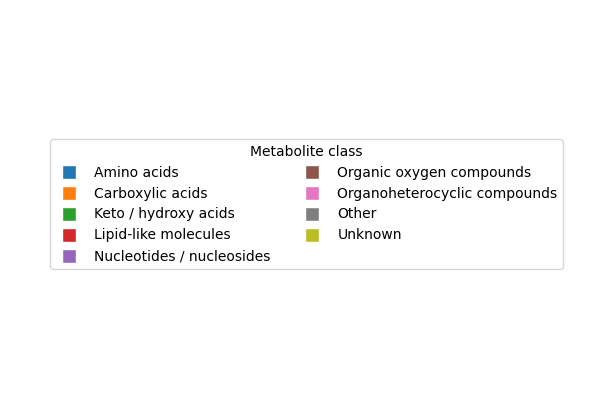

In [90]:
from matplotlib.lines import Line2D

legend_class_to_color = {cls: class_to_color[cls] for cls in class_to_color if cls != 'Mixed'}
# Create legend handles for each metabolite class
legend_handles = [
    Line2D([0], [1], marker='s', color='w', markerfacecolor=class_to_color[cls], markersize=10, label=cls)
    for cls in legend_class_to_color
]

# plt.legend(handles=legend_handles, title="Metabolite class", bbox_to_anchor=(1.01, 1), loc='upper left')
fig, ax = plt.subplots(figsize=(2, 4))
ax.axis('off')  # Hide axes
legend = ax.legend(handles=legend_handles, title="Metabolite class", loc='center', frameon=True, ncol=2)
plt.tight_layout()
plt.savefig(figure_folder / f'figure_5_circos_transporter_KO_metabolite_class_legend_{normalization}_norm_lam_{lam}.pdf', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_37588/385353907.py:13: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



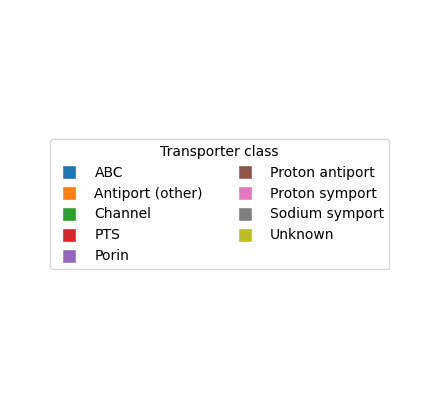

In [91]:
from matplotlib.lines import Line2D

# Create legend handles for each metabolite class
legend_handles = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor=type_to_color[cls], markersize=10, label=cls)
    for cls in type_to_color
]

# plt.legend(handles=legend_handles, title="Metabolite class", bbox_to_anchor=(1.01, 1), loc='upper left')
fig, ax = plt.subplots(figsize=(2, 4))
ax.axis('off')  # Hide axes
legend = ax.legend(handles=legend_handles, title="Transporter class", loc='center', frameon=True, ncol = 2)
plt.tight_layout()
plt.savefig(figure_folder / f'figure_5_circos_transporter_KO_transporter_class_legend_{normalization}_norm_lam_{lam}.pdf', dpi=300, bbox_inches='tight')
plt.show()

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
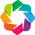

:Chord   [Strain,Metabolite]

In [92]:
import holoviews as hv
from holoviews import opts
hv.extension('bokeh')

# Prepare edge list
edges = sel_df[['Strain', 'Metabolite']].dropna().copy()
edges['Metabolite'] = edges['Metabolite'].apply(lambda x: f"met_{hash(x)}")  # anonymize metabolite nodes

# Count links per transporter and metabolite
transporter_counts = edges['Strain'].value_counts()
metabolite_counts = edges['Metabolite'].value_counts()

# Sort transporters and metabolites by number of links
sorted_transporters = transporter_counts.index.tolist()
sorted_metabolites = metabolite_counts.index.tolist()

# Build node list: sorted transporters + sorted metabolites
nodes = sorted_transporters + sorted_metabolites[::-1]

# Only label transporters
node_labels = {n: n if n in sorted_transporters else '' for n in nodes}

# Build chord diagram
chord = hv.Chord((edges, hv.Dataset(pd.DataFrame({'name': nodes, 'label': [node_labels[n] for n in nodes]}), 'name')))
chord.opts(
    opts.Chord(
        labels='label',
        node_color='label',
        edge_color='Strain',
        cmap='Category20',
        label_text_font_size='10pt',
        node_size=10,
        width=600, height=600,
        title="Transporter–Metabolite Circular Chord Diagram (Sorted Metabolites)"
    )
)

# Expression levels vs effect

Corr ribo prof: 0.2206845986701327, pval: 0.08220158700929277
Corr protein num frac: 0.21412299886117708, pval: 0.09196515408859009


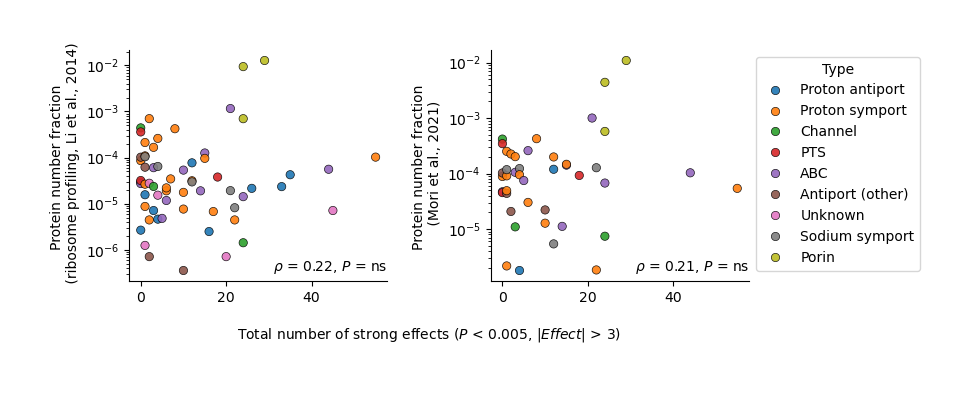

In [93]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,3))
sns.scatterplot(data = met_changest, x = 'Total', y = 'Ribosome profiling number fraction (Li et al., 2014)', ax = ax1, hue = 'Type', legend=False, edgecolor='k', alpha = 0.9)
l2 = sns.scatterplot(data = met_changest, x = 'Total', y = 'Mean protein number fraction (C-lim)', ax = ax2, hue = 'Type', edgecolor='k', alpha = 0.9)
sns.move_legend(l2, "upper left", bbox_to_anchor=(1, 1))
ax1.set_yscale('log')
ax2.set_yscale('log')
plt.subplots_adjust(wspace=0.4)
corr1, pval1 = st.pearsonr(met_changest['Total'], met_changest['Ribosome profiling number fraction (Li et al., 2014)'])
corr2, pval2 = st.pearsonr(met_changest['Total'], met_changest['Mean protein number fraction (C-lim)'])
ax1.text(1, 0.02, f'$ρ$ = {corr1:.2f}, $P$ = ns', transform=ax1.transAxes, ha='right', va='bottom')
ax2.text(1, 0.02, f'$ρ$ = {corr2:.2f}, $P$ = ns', transform=ax2.transAxes, ha='right', va='bottom')
print(f'Corr ribo prof: {corr1}, pval: {pval1}')
print(f'Corr protein num frac: {corr2}, pval: {pval2}')

fig.supxlabel(f'Total number of strong effects ($P$ < 0.005, |$Effect$| > {min_effect})', y = -0.1, size = 10)
ax1.set_xlabel('')
ax2.set_xlabel('')
ax1.set_ylabel('Protein number fraction \n (ribosome profiling, Li et al., 2014)')
ax2.set_ylabel('Protein number fraction \n (Mori et al., 2021)')

sns.despine()
plt.savefig(figure_folder / f'figure_5_number_of_changed_metabolites_vs_expression_transporter_KO_{normalization}_norm_lam_{lam}.pdf', dpi=300, bbox_inches='tight')

In [94]:
max_effect = sel_df.groupby('Strain').agg({'|Effect|': 'max'}).reset_index()
max_effect = max_effect.merge(df_tmeta, left_on='Strain', right_on='Gene Name', how='left')

Corr 1: 0.1696775096972306, pval: 0.21554462406610428
Corr 2: y0.21412299886117708, pval: 0.09196515408859009


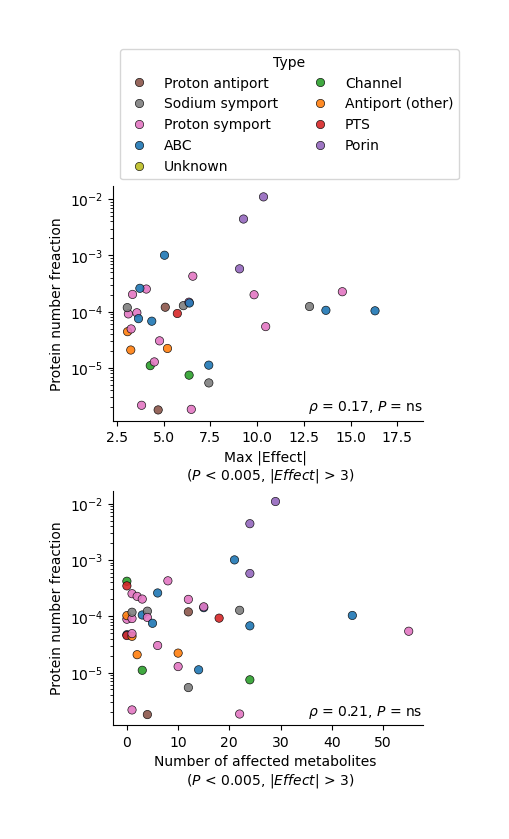

In [95]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4,7), sharey=True)

l1 = sns.scatterplot(data = max_effect, x = '|Effect|', y = 'Mean protein number fraction (C-lim)', ax = ax1, hue = 'Type', edgecolor='k', 
                alpha = 0.9, legend = True, palette=type_to_color)
l2 = sns.scatterplot(data = met_changest, x = 'Total', y = 'Mean protein number fraction (C-lim)', ax = ax2, hue = 'Type',
edgecolor='k', alpha = 0.9, palette=type_to_color, legend = False)




ax1.set_yscale('log')
ax2.set_yscale('log')
ax1.set_xlabel('Max |Effect| \n ($P$ < 0.005, |$Effect$| > 3)')
ax2.set_xlabel('Number of affected metabolites \n ($P$ < 0.005, |$Effect$| > 3)')
ax1.set_ylabel('Protein number freaction')
ax2.set_ylabel('Protein number freaction')
# ax2.set_ylabel('Mean protein number fraction \n (Mori et al., 2021)')
corr1, pval1 = st.pearsonr(max_effect['|Effect|'], max_effect['Mean protein number fraction (C-lim)'])
corr2, pval2 = st.pearsonr(met_changest['Total'], met_changest['Mean protein number fraction (C-lim)'])

ax1.text(1, 0.02, f'$ρ$ = {corr1:.2f}, $P$ = ns', transform=ax1.transAxes, ha='right', va='bottom')
ax2.text(1, 0.02, f'$ρ$ = {corr2:.2f}, $P$ = ns', transform=ax2.transAxes, ha='right', va='bottom')
print(f'Corr 1: {corr1}, pval: {pval1}')
print(f'Corr 2: y{corr2}, pval: {pval2}')

sns.despine()
sns.move_legend(l1, "lower left", bbox_to_anchor=(0, 1), ncol = 2)

plt.subplots_adjust(hspace=0.3)
plt.savefig(figure_folder / f'figure_5_number_of_changed_metabolites_effect_vs_expression_transporter_KO_{normalization}_norm_lam_{lam}.pdf', dpi=300, bbox_inches='tight')

Corr ribo prof: 0.18300709049306066, pval: 0.18110209471219008
Corr protein num frac: y0.1696775096972306, pval: 0.21554462406610428


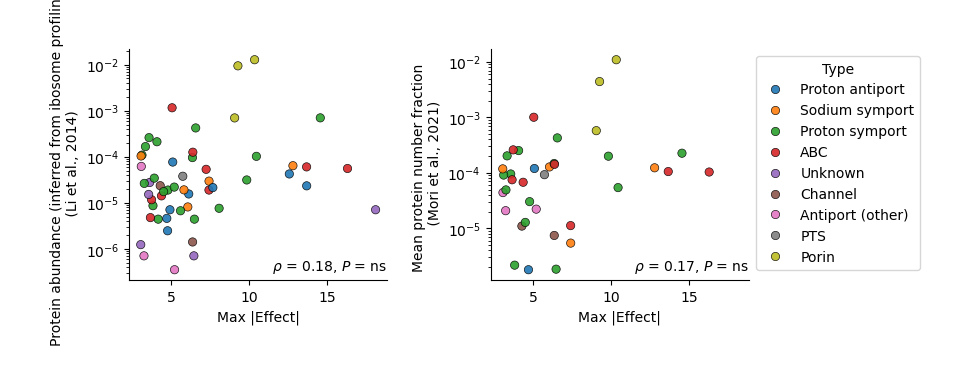

In [96]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,3))
sns.scatterplot(data = max_effect, x = '|Effect|', y = 'Ribosome profiling number fraction (Li et al., 2014)', ax = ax1, hue = 'Type', legend=False, edgecolor='k', alpha = 0.9)
l2 = sns.scatterplot(data = max_effect, x = '|Effect|', y = 'Mean protein number fraction (C-lim)', ax = ax2, hue = 'Type', edgecolor='k', alpha = 0.9)
sns.move_legend(l2, "upper left", bbox_to_anchor=(1, 1))
ax1.set_yscale('log')
ax2.set_yscale('log')
ax1.set_xlabel('Max |Effect|')
ax2.set_xlabel('Max |Effect|')
ax1.set_ylabel('Protein abundance (inferred from ibosome profiling \n (Li et al., 2014)')
ax2.set_ylabel('Mean protein number fraction \n (Mori et al., 2021)')
plt.subplots_adjust(wspace=0.4)
corr1, pval1 = st.pearsonr(max_effect['|Effect|'], max_effect['Ribosome profiling number fraction (Li et al., 2014)'])
corr2, pval2 = st.pearsonr(max_effect['|Effect|'], max_effect['Mean protein number fraction (C-lim)'])
ax1.text(1, 0.02, f'$ρ$ = {corr1:.2f}, $P$ = ns', transform=ax1.transAxes, ha='right', va='bottom')
ax2.text(1, 0.02, f'$ρ$ = {corr2:.2f}, $P$ = ns', transform=ax2.transAxes, ha='right', va='bottom')
print(f'Corr ribo prof: {corr1}, pval: {pval1}')
print(f'Corr protein num frac: y{corr2}, pval: {pval2}')
sns.despine()
plt.savefig(figure_folder / f'figure_5_effect_size_vs_expression_transporter_KO_{normalization}_norm_lam_{lam}.pdf', dpi=300, bbox_inches='tight')

In [97]:
max_effect = max_effect.merge(met_changest[['Strain', 'Total']], on='Strain', how='left')

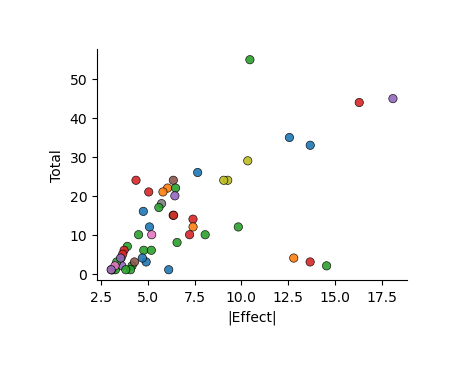

In [98]:
fig, ax1= plt.subplots(1, 1, figsize=(4,3))
l2 = sns.scatterplot(data = max_effect, x = '|Effect|', y = 'Total', ax = ax1, hue = 'Type', legend=False, edgecolor='k', alpha = 0.9)
# sns.move_legend(l2, "upper left", bbox_to_anchor=(1, 1))
sns.despine()
# plt.savefig(figure_folder / f'figure_5_number_of_changed_metabolites_vs_expression_transporter_KO_{normalization}_norm_lam_{lam}.pdf', dpi=300, bbox_inches='tight')

In [99]:
n_permutations = 1000
max_group_size = 60

all_group_sizes = []
all_max_effects = []
corr_list = []
pvals = []
    
N = sel_df.shape[0]
for _ in range(n_permutations):
    shuffled = sel_df.sample(frac=1).reset_index(drop=True)
    i = 0
    group_sizes = []
    max_effects = []
    while i < N:
        group_size = np.random.randint(1, max_group_size + 1)
        group_size = min(group_size, N - i)
        group = shuffled.iloc[i:i+group_size]
        group_sizes.append(len(group))
        max_effects.append(group['|Effect|'].max())
        i += group_size
    all_group_sizes += group_sizes
    all_max_effects += max_effects
    corr, pval = st.pearsonr(group_sizes, max_effects)
    corr_list.append(corr)
    pvals.append(pval)
corr, pval = st.pearsonr(all_group_sizes, all_max_effects)
print(f"Pearson correlation: {corr:.3f}, p-value: {pval:.2e}")


# # Optional: plot the relationship
# import matplotlib.pyplot as plt
# plt.scatter(group_sizes, max_effects, alpha=0.3)
# plt.xlabel('Number of effects in group')
# plt.ylabel('Max effect in group')
# plt.title(f'Correlation: {corr:.2f} (p={pval:.2g})')
# plt.show()

Pearson correlation: 0.536, p-value: 0.00e+00


In [100]:
rcorr, rpval = st.pearsonr(max_effect['Total'], max_effect['|Effect|'])

In [101]:
(np.array(corr_list)>= rcorr).sum()/n_permutations

np.float64(0.283)

In [102]:
np.mean(corr_list), np.std(corr_list)

(np.float64(0.5211865028187715), np.float64(0.16225373183639527))

In [103]:
corr.mean()

np.float64(0.5358097882245636)

In [104]:
print(st.pearsonr(met_changest['Total'], met_changest['log10(Ribosome profiling)']))
notna = met_changest['log10(Mean protein number fraction)'].notna()
st.pearsonr(met_changest.loc[notna, 'Total'], met_changest.loc[notna, 'log10(Mean protein number fraction)'])
# plt.scatter(met_changest['Total'], met_changest['log10(Ribosome profiling)'])

PearsonRResult(statistic=np.float64(0.07980169261895594), pvalue=np.float64(0.5341292050375931))


PearsonRResult(statistic=np.float64(0.15479140479352999), pvalue=np.float64(0.3216293416863179))

# Metabolite value

In [105]:
value_fn = data_folder / 'Z_div/I_metabolite_values_big_screen.csv'
df_values = pd.read_csv(value_fn)
df_values['log10(Metabolite value)'] = np.log10(df_values['Metabolite value'])
kegg_to_logvalue = df_values.set_index('kegg_id')['log10(Metabolite value)'].to_dict()
kegg_to_value = df_values.set_index('kegg_id')['Metabolite value'].to_dict()

In [106]:
for i, row in strain_changes.iterrows():
    values = [kegg_to_value.get(kegg, np.nan) for kegg in row['KEGG'].split(';')]
    logvalues = [kegg_to_logvalue.get(kegg, np.nan) for kegg in row['KEGG'].split(';')]
    strain_changes.at[i, 'log10(Metabolite value)'] = np.nanmean(logvalues)
    strain_changes.at[i, 'Metabolite value'] = np.nanmean(values)

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_37588/2547272601.py:4: RuntimeWarning:

Mean of empty slice

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_37588/2547272601.py:5: RuntimeWarning:

Mean of empty slice



Pearson correlation: 0.055, p-value: 0.597


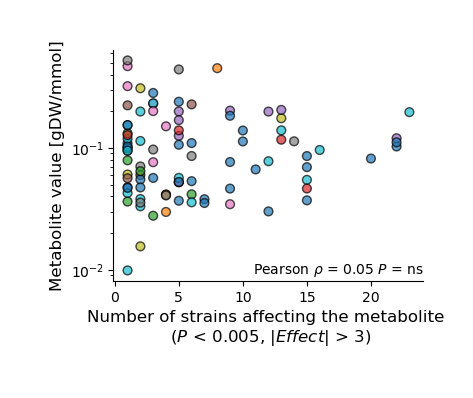

In [177]:

fig, ax = plt.subplots(figsize=(4,3))
sns.scatterplot(data = strain_changes, x='Total', y='Metabolite value',
                            ax = ax, edgecolor='k', s=40, alpha=0.7, legend=False,
                            linewidth=1, hue = 'Classification', palette=class_to_color)
rp = sns.regression._RegressionPlotter(strain_changes['Total'], strain_changes['log10(Metabolite value)'])

grid, yhat, err_bands = rp.fit_regression(ax=ax)
ax.set_yscale('log')
sns.despine()
plt.xlabel('Number of strains affecting the metabolite \n ($P$ < 0.005, $|Effect|$ > 3)', size = 12)
plt.ylabel('Metabolite value [gDW/mmol]', size = 12)

notnan = strain_changes['log10(Metabolite value)'].notna()
corr, pval = st.pearsonr(strain_changes.loc[notnan, 'Total'], strain_changes.loc[notnan, 'log10(Metabolite value)'])
print(f"Pearson correlation: {corr:.3f}, p-value: {pval:.3g}")
ax.text(1, 0.01, f'Pearson $ρ$ = {corr:.2f} $P$ = ns', transform=ax.transAxes, va = 'bottom', ha='right')
# sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), frameon=True)
plt.savefig(figure_folder / f'figure_5_number_of_strains_vs_metabolite_value_transporter_KO_{normalization}_norm_lam_{lam}.pdf', dpi=300, bbox_inches='tight')
        # create regression plotter object with log’d Y values

Pearson correlation: 0.125, p-value: 0.224


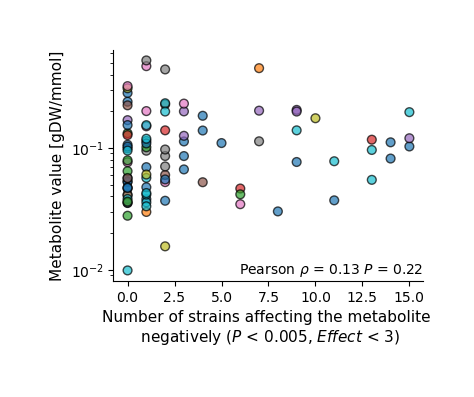

In [188]:

fig, ax = plt.subplots(figsize=(4,3))
sns.scatterplot(data = strain_changes, x='Decrease', y='Metabolite value',
                            ax = ax, edgecolor='k', s=40, alpha=0.7, legend=False,
                            linewidth=1, hue = 'Classification', palette=class_to_color)
# rp = sns.regression._RegressionPlotter(strain_changes['Decrease'], strain_changes['log10(Metabolite value)'])

# grid, yhat, err_bands = rp.fit_regression(ax=ax)
ax.set_yscale('log')
sns.despine()
plt.xlabel('Number of strains affecting the metabolite \n negatively ($P$ < 0.005, $Effect$ < 3)', size = 11)
plt.ylabel('Metabolite value [gDW/mmol]', size = 11)

notnan = strain_changes['log10(Metabolite value)'].notna()
corr, pval = st.pearsonr(strain_changes.loc[notnan, 'Decrease'], strain_changes.loc[notnan, 'log10(Metabolite value)'])
print(f"Pearson correlation: {corr:.3f}, p-value: {pval:.3g}")
ax.text(1, 0.01, f'Pearson $ρ$ = {corr:.2f} $P$ = {pval:.2g}', transform=ax.transAxes, va = 'bottom', ha='right')
# sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), frameon=True)
plt.savefig(figure_folder / f'figure_5_number_of_strains_vs_metabolite_value_transporter_KO_{normalization}_norm_lam_{lam}_decrease.pdf', dpi=300, bbox_inches='tight')
        # create regression plotter object with log’d Y values

Pearson correlation: -0.080, p-value: 0.436


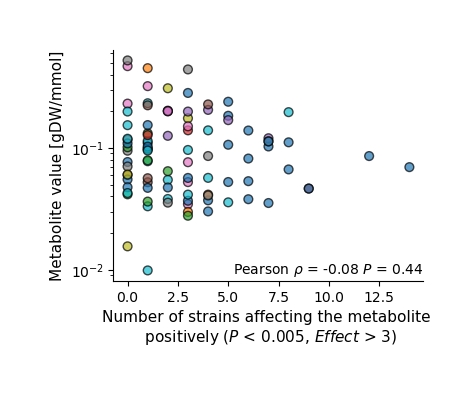

In [190]:

fig, ax = plt.subplots(figsize=(4,3))
sns.scatterplot(data = strain_changes, x='Increase', y='Metabolite value',
                            ax = ax, edgecolor='k', s=40, alpha=0.7, legend=False,
                            linewidth=1, hue = 'Classification', palette=class_to_color)
# rp = sns.regression._RegressionPlotter(strain_changes['Increase'], strain_changes['log10(Metabolite value)'])

# grid, yhat, err_bands = rp.fit_regression(ax=ax)
ax.set_yscale('log')
sns.despine()
plt.xlabel('Number of strains affecting the metabolite \n positively ($P$ < 0.005, $Effect$ > 3)', size = 11)
plt.ylabel('Metabolite value [gDW/mmol]', size = 11)

notnan = strain_changes['log10(Metabolite value)'].notna()
corr, pval = st.pearsonr(strain_changes.loc[notnan, 'Increase'], strain_changes.loc[notnan, 'log10(Metabolite value)'])
print(f"Pearson correlation: {corr:.3f}, p-value: {pval:.3g}")
ax.text(1, 0.01, f'Pearson $ρ$ = {corr:.2f} $P$ = {pval:.2g}', transform=ax.transAxes, va = 'bottom', ha='right')
# sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), frameon=True)
plt.savefig(figure_folder / f'figure_5_number_of_strains_vs_metabolite_value_transporter_KO_{normalization}_norm_lam_{lam}_increase.pdf', dpi=300, bbox_inches='tight')


## Metabolite value vs. effect size (Rel. distance)

In [142]:
# Per-metabolite value lookup from strain_changes (already has value mapped via KEGG)
sc_val = strain_changes[['Metabolite', 'log10(Metabolite value)', 'Metabolite value', 'Classification']].dropna(subset=['log10(Metabolite value)'])

# 1. Mean |Rel. distance| among significant strains per metabolite (from sel_df)
mean_eff_sig = (sel_df.groupby('Metabolite')['Rel. distance']
                .apply(lambda x: x.abs().mean())
                .reset_index(name='Mean |Rel. distance|'))
mean_eff_sig = mean_eff_sig.merge(sc_val, on='Metabolite', how='inner')

# 2. Mean |Rel. distance| across ALL strains per metabolite (from dis_mz — avoids significance-threshold bias)
mean_eff_all = (dis_mz.groupby('Metabolite')['Rel. distance']
                .apply(lambda x: x.abs().mean())
                .reset_index(name='Mean |Rel. distance|'))
mean_eff_all = mean_eff_all.merge(sc_val, on='Metabolite', how='inner')
mean_eff_all['Value quartile'] = pd.qcut(mean_eff_all['log10(Metabolite value)'], q=4,
                                          labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])

# 3. Individual strain-metabolite pairs from sel_df with value (for density scatter)
sel_df_val = sel_df.merge(sc_val[['Metabolite', 'log10(Metabolite value)']], on='Metabolite', how='left')
sel_df_val = sel_df_val.dropna(subset=['log10(Metabolite value)'])
sel_df_val['|Rel. distance|'] = sel_df_val['Rel. distance'].abs()

print(f"Metabolites with value data: sig strains={len(mean_eff_sig)}, all strains={len(mean_eff_all)}, individual pairs={len(sel_df_val)}")

Metabolites with value data: sig strains=96, all strains=96, individual pairs=587


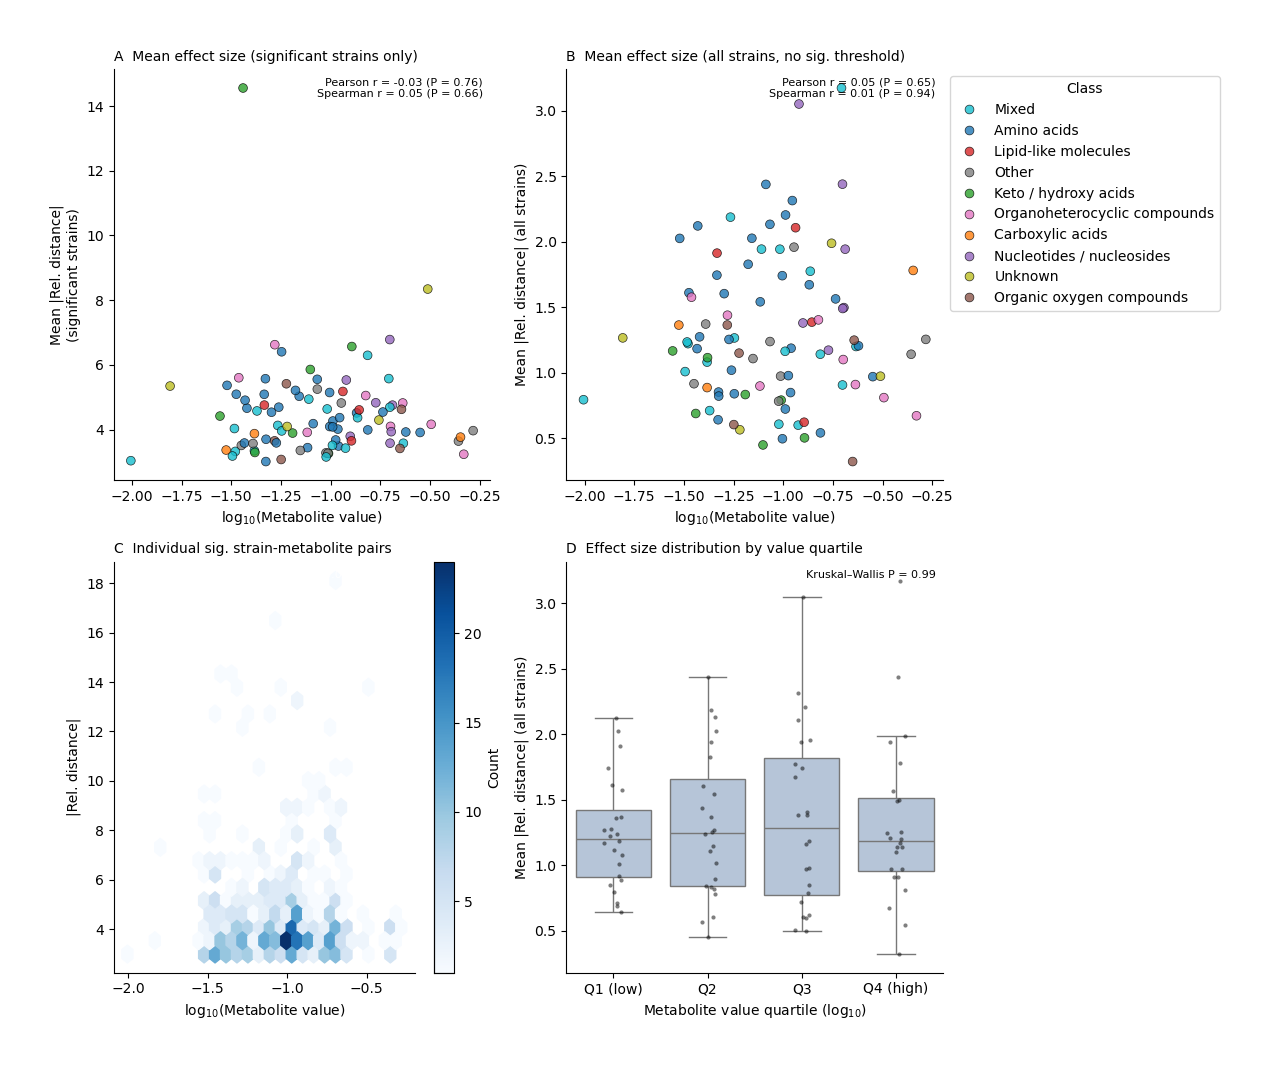

In [143]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- A: Mean |effect| per metabolite (significant strains only) vs log10(value) ---
ax = axes[0, 0]
sns.scatterplot(data=mean_eff_sig, x='log10(Metabolite value)', y='Mean |Rel. distance|',
                hue='Classification', palette=class_to_color,
                edgecolor='k', linewidth=0.5, s=40, alpha=0.8, ax=ax)
notnan = mean_eff_sig[['log10(Metabolite value)', 'Mean |Rel. distance|']].notna().all(axis=1)
corr_p, pval_p = st.pearsonr(mean_eff_sig.loc[notnan, 'log10(Metabolite value)'],
                               mean_eff_sig.loc[notnan, 'Mean |Rel. distance|'])
corr_s, pval_s = st.spearmanr(mean_eff_sig.loc[notnan, 'log10(Metabolite value)'],
                                mean_eff_sig.loc[notnan, 'Mean |Rel. distance|'])
ax.text(0.98, 0.98,
        f'Pearson r = {corr_p:.2f} (P = {pval_p:.2g})\nSpearman r = {corr_s:.2f} (P = {pval_s:.2g})',
        transform=ax.transAxes, va='top', ha='right', fontsize=8)
ax.set_xlabel('log$_{10}$(Metabolite value)')
ax.set_ylabel('Mean |Rel. distance|\n(significant strains)')
ax.set_title('A  Mean effect size (significant strains only)', loc='left', fontsize=10)
ax.get_legend().remove()

# --- B: Mean |effect| per metabolite (ALL strains) vs log10(value) ---
ax = axes[0, 1]
sns.scatterplot(data=mean_eff_all, x='log10(Metabolite value)', y='Mean |Rel. distance|',
                hue='Classification', palette=class_to_color,
                edgecolor='k', linewidth=0.5, s=40, alpha=0.8, ax=ax)
notnan = mean_eff_all[['log10(Metabolite value)', 'Mean |Rel. distance|']].notna().all(axis=1)
corr_p, pval_p = st.pearsonr(mean_eff_all.loc[notnan, 'log10(Metabolite value)'],
                               mean_eff_all.loc[notnan, 'Mean |Rel. distance|'])
corr_s, pval_s = st.spearmanr(mean_eff_all.loc[notnan, 'log10(Metabolite value)'],
                                mean_eff_all.loc[notnan, 'Mean |Rel. distance|'])
ax.text(0.98, 0.98,
        f'Pearson r = {corr_p:.2f} (P = {pval_p:.2g})\nSpearman r = {corr_s:.2f} (P = {pval_s:.2g})',
        transform=ax.transAxes, va='top', ha='right', fontsize=8)
ax.set_xlabel('log$_{10}$(Metabolite value)')
ax.set_ylabel('Mean |Rel. distance| (all strains)')
ax.set_title('B  Mean effect size (all strains, no sig. threshold)', loc='left', fontsize=10)
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1), frameon=True, title='Class')

# --- C: Hexbin density — individual sig. strain-metabolite pairs vs value ---
ax = axes[1, 0]
hb = ax.hexbin(sel_df_val['log10(Metabolite value)'], sel_df_val['|Rel. distance|'],
               gridsize=25, cmap='Blues', mincnt=1)
plt.colorbar(hb, ax=ax, label='Count')
corr_s, pval_s = st.spearmanr(sel_df_val['log10(Metabolite value)'], sel_df_val['|Rel. distance|'])
ax.text(0.98, 0.98, f'Spearman r = {corr_s:.2f} (P = {pval_s:.2g})',
        transform=ax.transAxes, va='top', ha='right', fontsize=8, color='white')
ax.set_xlabel('log$_{10}$(Metabolite value)')
ax.set_ylabel('|Rel. distance|')
ax.set_title('C  Individual sig. strain-metabolite pairs', loc='left', fontsize=10)

# --- D: Boxplot of mean |effect| (all strains) grouped by value quartile ---
ax = axes[1, 1]
quartile_order = ['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)']
sns.boxplot(data=mean_eff_all, x='Value quartile', y='Mean |Rel. distance|',
            order=quartile_order, color='lightsteelblue', ax=ax, fliersize=0)
sns.stripplot(data=mean_eff_all, x='Value quartile', y='Mean |Rel. distance|',
              order=quartile_order, color='k', size=3, alpha=0.5, ax=ax, jitter=True)
groups_kw = [grp['Mean |Rel. distance|'].values
             for _, grp in mean_eff_all.groupby('Value quartile', observed=True)]
kw_stat, kw_pval = st.kruskal(*groups_kw)
ax.text(0.98, 0.98, f'Kruskal–Wallis P = {kw_pval:.2g}',
        transform=ax.transAxes, va='top', ha='right', fontsize=8)
ax.set_xlabel('Metabolite value quartile (log$_{10}$)')
ax.set_ylabel('Mean |Rel. distance| (all strains)')
ax.set_title('D  Effect size distribution by value quartile', loc='left', fontsize=10)

sns.despine()
plt.tight_layout()
plt.savefig(figure_folder / f'figure_5_value_vs_effect_size_analyses_{normalization}_norm_lam_{lam}.pdf',
            dpi=300, bbox_inches='tight')

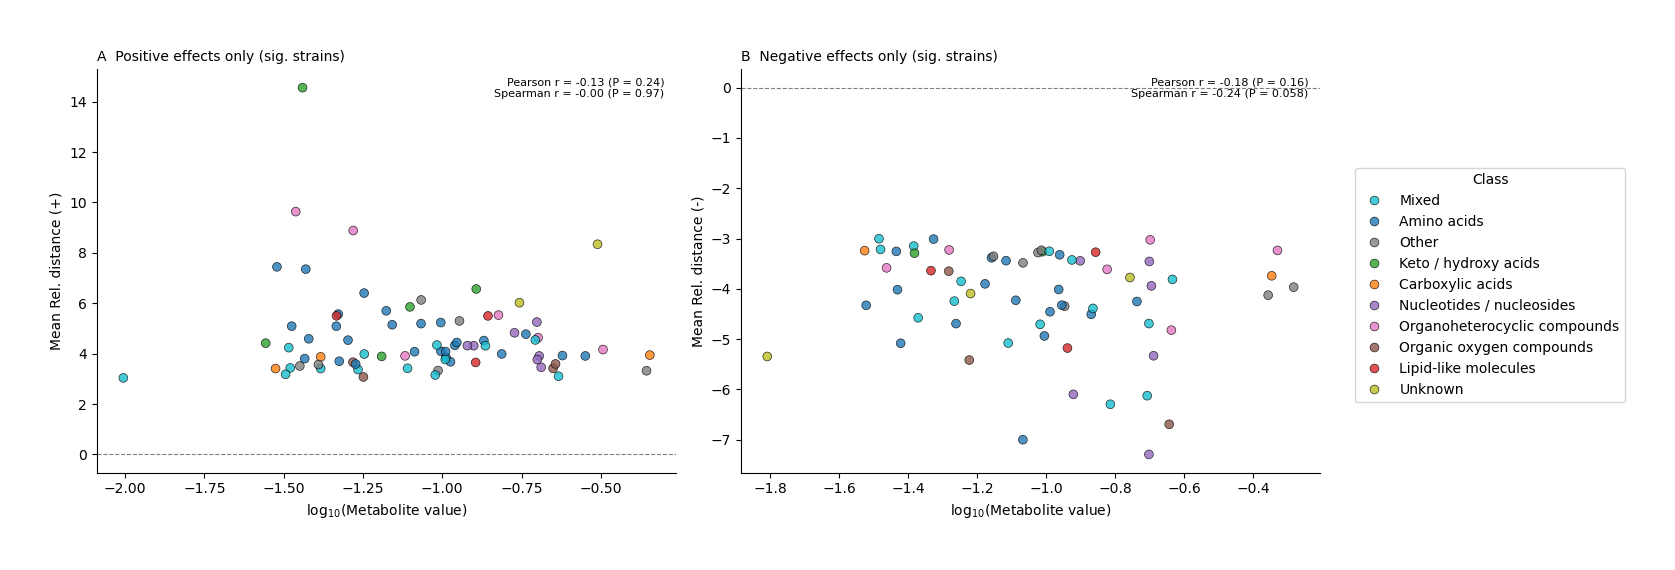

Metabolites with positive effects: 77  |  negative effects: 65


In [191]:

# Mean positive / negative effect per metabolite (significant strains only) vs value
mean_eff_pos = (sel_df[sel_df['Rel. distance'] > 0]
                .groupby('Metabolite')['Rel. distance']
                .mean()
                .reset_index(name='Mean Rel. distance (+)'))
mean_eff_pos = mean_eff_pos.merge(sc_val, on='Metabolite', how='inner')

mean_eff_neg = (sel_df[sel_df['Rel. distance'] < 0]
                .groupby('Metabolite')['Rel. distance']
                .mean()
                .reset_index(name='Mean Rel. distance (-)'))
mean_eff_neg = mean_eff_neg.merge(sc_val, on='Metabolite', how='inner')

fig2, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5))

for ax, df, ycol, title in [
    (axA, mean_eff_pos, 'Mean Rel. distance (+)', 'A  Positive effects only (sig. strains)'),
    (axB, mean_eff_neg, 'Mean Rel. distance (-)', 'B  Negative effects only (sig. strains)'),
]:
    sns.scatterplot(data=df, x='log10(Metabolite value)', y=ycol,
                    hue='Classification', palette=class_to_color,
                    edgecolor='k', linewidth=0.5, s=40, alpha=0.8, ax=ax)
    notnan = df[['log10(Metabolite value)', ycol]].notna().all(axis=1)
    if notnan.sum() > 2:
        corr_p, pval_p = st.pearsonr(df.loc[notnan, 'log10(Metabolite value)'], df.loc[notnan, ycol])
        corr_s, pval_s = st.spearmanr(df.loc[notnan, 'log10(Metabolite value)'], df.loc[notnan, ycol])
        ax.text(0.98, 0.98,
                f'Pearson r = {corr_p:.2f} (P = {pval_p:.2g})\nSpearman r = {corr_s:.2f} (P = {pval_s:.2g})',
                transform=ax.transAxes, va='top', ha='right', fontsize=8)
    ax.axhline(0, ls='--', c='grey', lw=0.8)
    ax.set_xlabel('log$_{10}$(Metabolite value)')
    ax.set_ylabel(ycol)
    ax.set_title(title, loc='left', fontsize=10)
    ax.get_legend().remove()

# shared legend on the right
handles, labels = axA.get_legend_handles_labels()
fig2.legend(handles, labels, title='Class', bbox_to_anchor=(1.01, 0.5), loc='center left', frameon=True)

sns.despine()
plt.tight_layout()
plt.savefig(figure_folder / f'figure_5_pos_neg_effects_vs_value_{normalization}_norm_lam_{lam}.pdf',
            dpi=300, bbox_inches='tight')
plt.show()
print(f'Metabolites with positive effects: {len(mean_eff_pos)}  |  negative effects: {len(mean_eff_neg)}')


# Auxotroph cocultures

In [144]:

auxotroph_cfus_fn = data_folder / 'E_auxotroph_coculture_CFUs.csv'
cfu_df = pd.read_csv(auxotroph_cfus_fn, index_col=0)

In [145]:
auxo_to_met = {
    'proC': 'Proline',
    'metB': 'Methionine',
    'ilvE': '(Iso)Leucine',
}

In [146]:
cfu_df.sort_values(by='Partner', inplace = True)

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_37588/3396353326.py:4: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_37588/3396353326.py:4: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_37588/3396353326.py:4: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_37588/3396353326.py:21: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



('proP',) 0.49003980762407173
('putP',) 1.7159516295269512e-06
('brnQ',) 0.03183793298521439
('cstA',) 0.5340884926014211
('metI',) 0.010483573563290308
('mtr',) 0.004979996933359521


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_37588/3396353326.py:21: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_37588/3396353326.py:21: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



('glnP',) 0.03557615190945062
('tsx',) 0.7464657174135358
('yeaS',) 0.11013197933609302
('ygaZ',) 0.002239056427148503


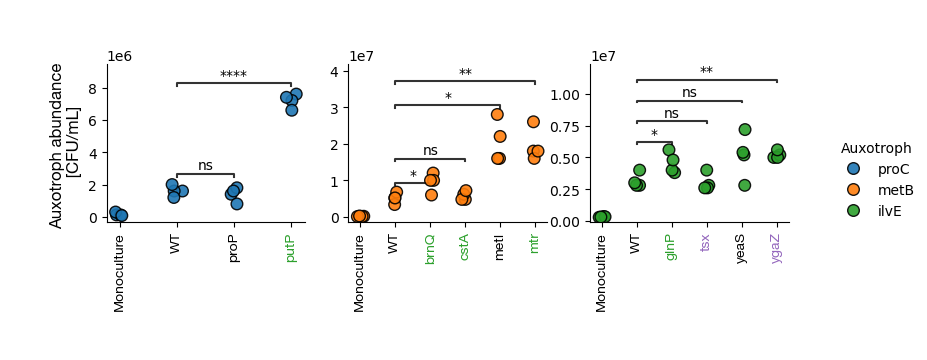

In [147]:
g = sns.catplot(data = cfu_df, x = 'Partner', kind = 'strip', col = 'Auxotroph', y = 'Auxotroph abundance [CFU/mL]',
            hue = 'Auxotroph', col_wrap=3, sharex=False, sharey=False, height = 2.5, lw = 1, edgecolor='k', alpha=0.9, s=70)
for ax in g.axes.flatten():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.set_xlabel('')
g.set_titles('')#col_template = 'Auxotroph: {col_name}')
g.axes[0].set_ylabel('Auxotroph abundance \n [CFU/mL]', fontdict={'size': 12, 'font': 'Helvetica Neue'})
# plt.tight_layout()
from statannotations.Annotator import Annotator

for ax, auxotroph in zip(g.axes.flatten(), cfu_df['Auxotroph'].unique()):
    aux_idx = cfu_df['Auxotroph'] == auxotroph
    partners = [p for p in cfu_df.loc[aux_idx, 'Partner'].unique() if p not in ['WT', 'Monoculture']]
    pairs = [(p, 'WT') for p in partners]
    data_aux = cfu_df[cfu_df['Auxotroph'] == auxotroph]
    annotator = Annotator(ax, pairs, data=data_aux, x='Partner', y='Auxotroph abundance [CFU/mL]')
    annotator.configure(test='t-test_welch', text_format='star', loc='inside', verbose=0)
    # annotator.apply_and_annotate()
    annotator.apply_test(alternative = 'two-sided')#,  equal_var=False)
    annotator.annotate()
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontdict={'size': 12, 'font': 'Helvetica Neue'})
    ax.set_xlabel('')
    for annot in annotator.annotations:
        print(annot.data.group2, annot.data.pvalue)
    # Color xlabels for partners with effect > 3
    for tick in ax.get_xticklabels():
        partner = tick.get_text()
        # Find effect for this partner and auxotroph
        effect_row = sel_df[(sel_df['Strain'] == partner) & (sel_df['Metabolite'] == auxo_to_met.get(auxotroph, None))]
        if not effect_row.empty and effect_row['Rel. distance'].values[0] > 0:
            tick.set_color('C2')
            tick.set_fontweight('bold')
        elif not effect_row.empty and effect_row['Rel. distance'].values[0] < 0:
            tick.set_color('C4')
            tick.set_fontweight('bold')
        else:
            tick.set_color('black')

plt.savefig(figure_folder / f'figure_5_auxotroph_coculture_CFU_abundances.pdf', dpi=300, bbox_inches='tight')

In [148]:
dis_mz.loc[dis_mz['Metabolite'] == '(Iso)Leucine']

,Strain,ionMz,Rel. abs. distance,Rel. distance,Mean abs. distance,Mean distance,MAE1,MAE2,Mean MAE,Strain 1,Strain 2,p-value rel,p-value abs,Metabolite,KEGG,All metabolite names,Alt. annotations,Classes,Classification,Name
54,yeaS,130.0876,2.566054,2.554862,0.384642,0.382965,0.253898,0.045895,0.149896,yeaS,WT,0.000,0.000,(Iso)Leucine,C00123;C00407,Isoleucine / (Iso)Leucine,Isoleucine,Amino acids,Amino acids,(Iso)Leucine
300,punC,130.0876,1.816287,0.679208,0.106344,0.039768,0.071205,0.045895,0.058550,punC,WT,0.064,0.000,(Iso)Leucine,C00123;C00407,Isoleucine / (Iso)Leucine,Isoleucine,Amino acids,Amino acids,(Iso)Leucine
546,rhtA,130.0876,1.274227,0.954923,0.088625,0.066417,0.093209,0.045895,0.069552,rhtA,WT,0.012,0.021,(Iso)Leucine,C00123;C00407,Isoleucine / (Iso)Leucine,Isoleucine,Amino acids,Amino acids,(Iso)Leucine
792,sstT,130.0876,0.455069,0.370897,0.055087,0.044898,0.196211,0.045895,0.121053,sstT,WT,0.175,0.900,(Iso)Leucine,C00123;C00407,Isoleucine / (Iso)Leucine,Isoleucine,Amino acids,Amino acids,(Iso)Leucine
1038,tsx,130.0876,4.821912,-4.116303,0.275758,-0.235405,0.068482,0.045895,0.057189,tsx,WT,0.000,0.000,(Iso)Leucine,C00123;C00407,Isoleucine / (Iso)Leucine,Isoleucine,Amino acids,Amino acids,(Iso)Leucine
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15011,metI,130.0874,0.366065,-0.275947,0.062381,-0.047024,0.133662,0.207160,0.170411,metI,WT,0.218,0.914,(Iso)Leucine,C00123;C00407,Isoleucine / (Iso)Leucine,Isoleucine,Amino acids,Amino acids,(Iso)Leucine
15573,yahN,130.0874,0.614860,-0.014474,0.103485,-0.002436,0.129453,0.207161,0.168307,yahN,WT,0.408,0.395,(Iso)Leucine,C00123;C00407,Isoleucine / (Iso)Leucine,Isoleucine,Amino acids,Amino acids,(Iso)Leucine
15854,kgtP,130.0874,0.556223,-0.482928,0.104139,-0.090416,0.167288,0.207161,0.187225,kgtP,WT,0.057,0.596,(Iso)Leucine,C00123;C00407,Isoleucine / (Iso)Leucine,Isoleucine,Amino acids,Amino acids,(Iso)Leucine
16135,manY,130.0874,0.792992,0.513716,0.148459,0.096175,0.167266,0.207161,0.187214,manY,WT,0.060,0.138,(Iso)Leucine,C00123;C00407,Isoleucine / (Iso)Leucine,Isoleucine,Amino acids,Amino acids,(Iso)Leucine


In [150]:
mean_cfu = cfu_df.groupby(['Partner', 'Auxotroph'])['Auxotroph abundance [CFU/mL]'].agg(['mean', 'std']).reset_index()

In [151]:
diff_data = []
for i, row in mean_cfu.iterrows():
    if row['Partner'] in ['Monoculture', 'WT']:
        continue
    # print(row)
    wt_idx = (mean_cfu['Partner'] == 'WT') & (mean_cfu['Auxotroph'] == row['Auxotroph'])
    diff = row['mean'] - mean_cfu.loc[wt_idx, 'mean'].values[0]
    std_wt = mean_cfu.loc[wt_idx, 'std'].values[0]
    pooled_std = np.sqrt(row['std']**2 + std_wt**2)

    # Get effect
    effect_idx = (dis_mz.Strain==row['Partner'])&(dis_mz.Metabolite == auxo_to_met[row['Auxotroph']])
    if effect_idx.sum() == 0:
        net_effect = np.nan
    else:
        net_effect = dis_mz.loc[effect_idx, 'Rel. distance'].values[0]
    diff_data.append([row['Auxotroph'], row['Partner'], diff, pooled_std, net_effect])

    print(f"{row['Auxotroph']} with {row['Partner']}: {row['mean']:.2e} ± {row['std']:.2e} CFU/mL")

metB with brnQ: 9.50e+06 ± 2.52e+06 CFU/mL
metB with cstA: 5.75e+06 ± 1.17e+06 CFU/mL
ilvE with glnP: 4.55e+06 ± 8.23e+05 CFU/mL
metB with metI: 2.05e+07 ± 5.74e+06 CFU/mL
metB with mtr: 1.95e+07 ± 4.43e+06 CFU/mL
proC with proP: 1.40e+06 ± 4.32e+05 CFU/mL
proC with putP: 7.20e+06 ± 4.32e+05 CFU/mL
ilvE with tsx: 3.00e+06 ± 6.73e+05 CFU/mL
ilvE with yeaS: 5.15e+06 ± 1.81e+06 CFU/mL
ilvE with ygaZ: 5.20e+06 ± 2.83e+05 CFU/mL


In [152]:
diff_auxo = pd.DataFrame(diff_data, columns=['Auxotroph', 'Partner', 'Diff CFU', 'Diff CFU std', 'Net effect'])

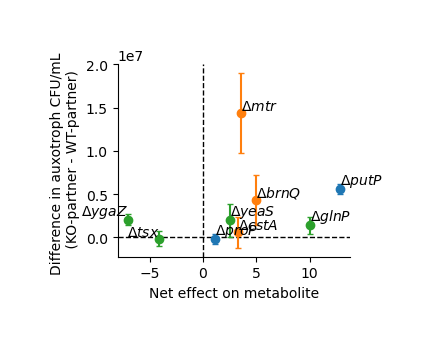

In [153]:
fig, ax = plt.subplots(figsize=(3,2.5))
ax.axvline(0, color='k', ls='--', lw=1)
ax.axhline(0, color='k', ls='--', lw=1)
aux_to_color = {'proC': 'C0', 'metB': 'C1', 'ilvE': 'C2'}
for i, row in diff_auxo.iterrows():
    ax.errorbar(row['Net effect'], row['Diff CFU'], yerr=row['Diff CFU std'], 
    fmt='o', color=aux_to_color[row['Auxotroph']],
     capsize=2)
    ax.text(row['Net effect'], row['Diff CFU'], f'Δ${row['Partner']}$', fontsize=10, ha='right' if row['Net effect']<0 else 'left', va='bottom')
sns.despine()
plt.xlabel('Net effect on metabolite')
plt.ylabel('Difference in auxotroph CFU/mL \n (KO-partner - WT-partner)')
plt.savefig(figure_folder / f'figure_5_auxotroph_coculture_CFUs_vs_net_effect_{normalization}_norm_lam_{lam}.pdf', dpi=300, bbox_inches='tight')

In [154]:
notnan = diff_auxo['Net effect'].notna()
st.pearsonr(diff_auxo.loc[notnan, 'Diff CFU'], diff_auxo.loc[notnan, 'Net effect'])

PearsonRResult(statistic=np.float64(0.2698453719459174), pvalue=np.float64(0.4825495470720716))

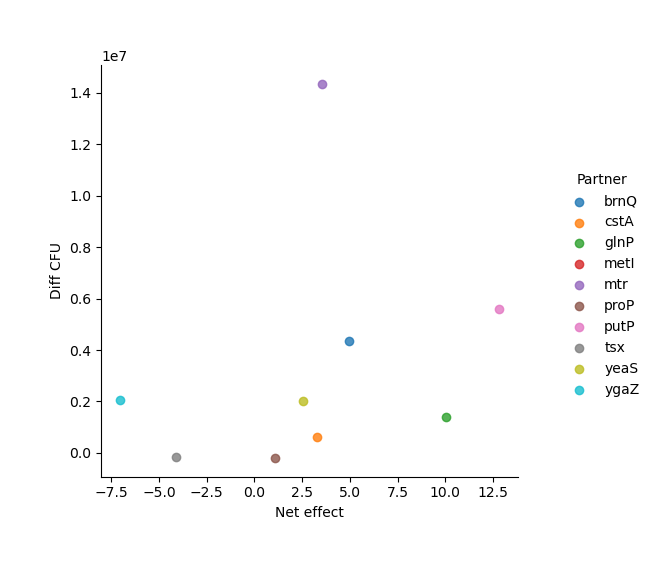

In [155]:
sns.lmplot(data = diff_auxo, x='Net effect', y='Diff CFU', hue='Partner')

In [156]:
diff_data = []
for auxotroph in cfu_df['Auxotroph'].unique():
    wt_mean = cfu_df.loc[(cfu_df.Partner == 'WT')&(cfu_df.Auxotroph == auxotroph), 'Auxotroph abundance [CFU/mL]'].mean()
    aux_data = cfu_df.loc[cfu_df.Auxotroph == auxotroph].copy()
    for i, row in aux_data.iterrows():
        if row['Partner'] in ['WT', 'Monoculture']:
            continue
        diff = row['Auxotroph abundance [CFU/mL]'] - wt_mean
        diff_data.append([row['Partner'], auxotroph, row['Well'], diff])
diff_df = pd.DataFrame(diff_data, columns=['Partner', 'Auxotroph', 'Well', 'Difference_vs_WT'])

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_37588/1010816180.py:4: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_37588/1010816180.py:4: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_37588/1010816180.py:4: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



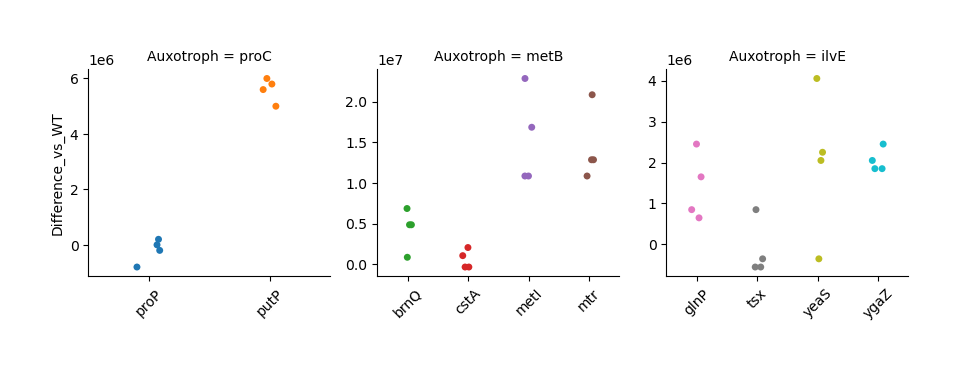

In [157]:
g = sns.catplot(data = diff_df, x = 'Partner', kind = 'strip', col = 'Auxotroph', y = 'Difference_vs_WT',
            hue = 'Partner', col_wrap=3, sharex=False, sharey=False, height = 3)
for ax in g.axes.flatten():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.set_xlabel('')
# ax.set_ylabel('Auxotroph abundance [CFU/mL]', fontsize = 7)
# plt.tight_layout()

# Plot bar charts

In [ ]:
sel_df = dis_mz.loc[sel_idx].copy()

In [ ]:
all_strains = dis_mz['Strain'].unique()
N_changed_mets = sel_df.groupby('Strain')['Kept names'].count().reindex(all_strains, fill_value=0).sort_values(ascending=False)
N_changed_mets_neg = sel_df.loc[sel_df['Rel. distance'] < 0].groupby('Strain')['Kept names'].count().reindex(all_strains, fill_value=0).sort_values(ascending=False)
N_changed_mets_pos = sel_df.loc[sel_df['Rel. distance'] > 0].groupby('Strain')['Kept names'].count().reindex(all_strains, fill_value=0).sort_values(ascending=False)

In [ ]:
met_changes = pd.merge(N_changed_mets_neg, N_changed_mets_pos, left_index=True, right_index=True, how='outer')
met_changes.columns = ['Decrease', 'Increase']
met_changes = met_changes.reset_index()
met_changes.dropna(inplace=True)

In [ ]:
met_changes['Total'] = met_changes['Decrease'] + met_changes['Increase']

In [ ]:
met_changes.sort_values(by='Total', ascending=False)

,Strain,Decrease,Increase,Total
2,adeP,24,36,60
41,punC,21,28,49
19,glnP,26,21,47
60,ygaZ,31,7,38
46,rhtC,12,23,35
...,...,...,...,...
12,dcuA,0,0,0
45,rhtB,0,0,0
25,hisQ,0,0,0
34,nupC,0,0,0


In [ ]:
met_changesL = met_changes.reset_index().melt(id_vars='Strain', var_name='Release', 
value_name='Number of changed metabolites', value_vars=['Increase', 'Decrease'])
met_changesL['Total'] = met_changesL.Strain.map(met_changes.set_index('Strain')['Total'].to_dict())

In [ ]:
met_changes.sort_values(by=['Total', 'Strain'], ascending=[False, True], inplace=True)

In [ ]:
ax.get_xticklabels()[0]

Text(0, 0, "ΔText(0, 0, 'adeP')")

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_2719/3284901492.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'Δ${lbl}$' for lbl in met_changes['Strain']], rotation=90)


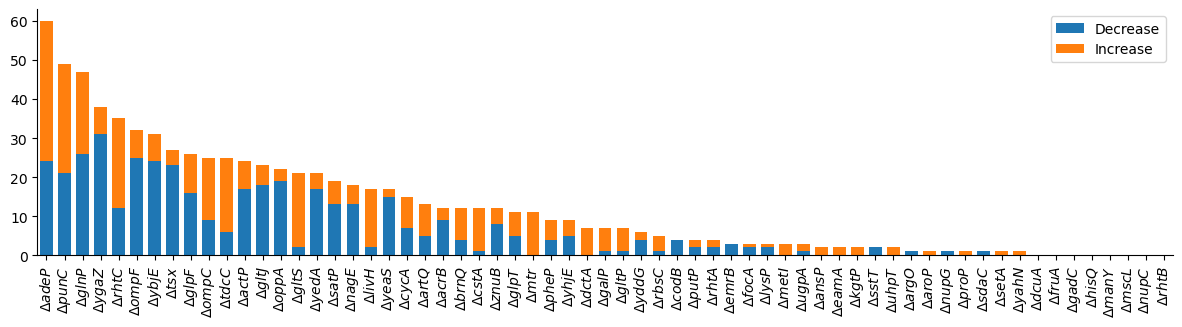

In [ ]:
fig, ax = plt.subplots(figsize = (12,3))
bar_width = 0.7  # Adjust this value for wider/narrower bars

ax.bar(met_changes['Strain'], height = met_changes['Decrease'], width=bar_width, label='Decrease')
ax.bar(met_changes['Strain'], height =  met_changes['Increase'], bottom=met_changes['Decrease'], width=bar_width, label='Increase')
plt.xlim(-0.5, len(met_changes['Strain'])-0.5)
ax.legend()
plt.tight_layout()
ax.set_xticklabels([f'Δ${lbl}$' for lbl in met_changes['Strain']], rotation=90)
# ax.set_ylabel('Number of affected metabolites \n (Effect > %s and p-value < %s)'%(rel_dis_limit, p_val_limit))
sns.despine()
plt.show()


# Histograms

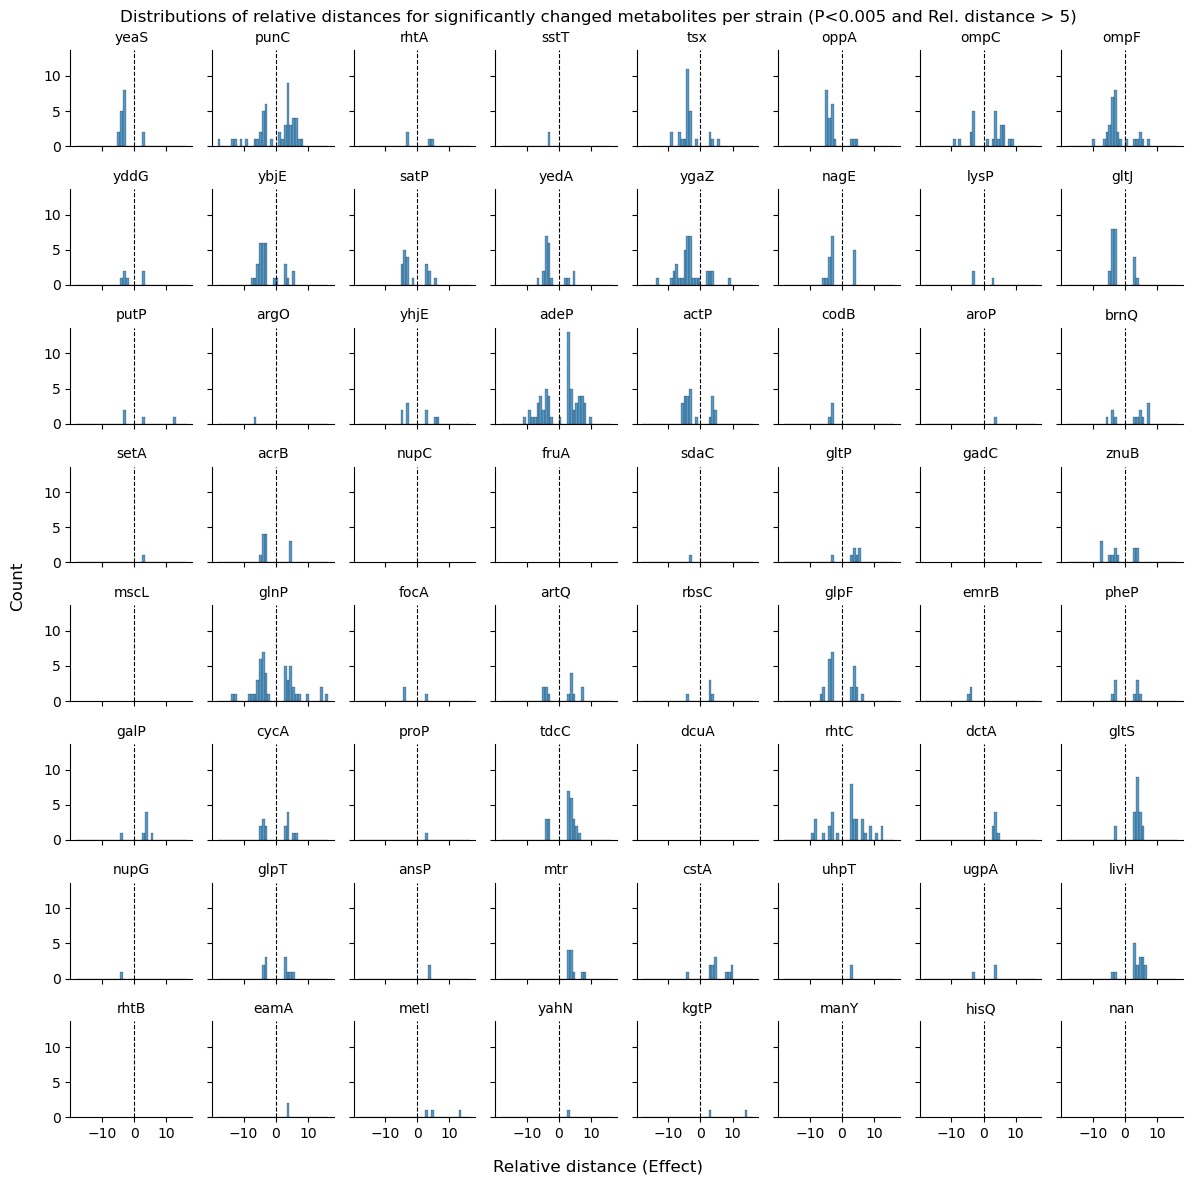

In [ ]:
g = sns.displot(sel_df,  x='Rel. distance', col = 'Strain', 
                col_wrap=8, bins = 40, col_order=met_changes.index, height = 1.5)#, hue = 'Batch')
for ax in g.axes.flatten():
    ax.axvline(0, c = 'k', ls = '--', lw = 0.8)
    ax.set_xlabel('')
    ax.set_ylabel('')
g.set_titles(col_template = '{col_name}', size = 10)
g.fig.suptitle('Distributions of relative distances for significantly changed metabolites per strain (P<0.005 and Rel. distance > 5)')
g.fig.supxlabel(r'Relative distance (Effect)', y=0.01, fontsize=12)
g.fig.supylabel('Count', x=0.01, fontsize=12)
    # ax.annotate(0.05, 0.05, )
# plt.yscale('log')
plt.tight_layout()

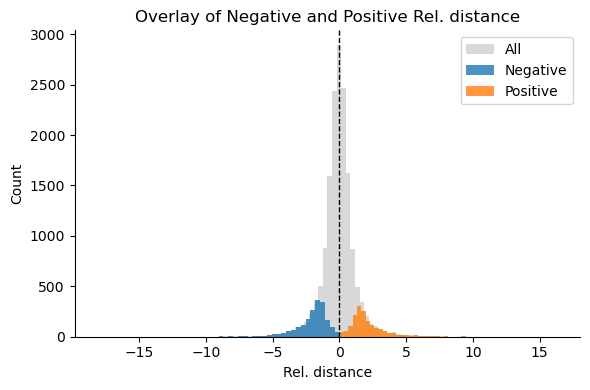

In [ ]:
plt.figure(figsize=(6, 4))
data = dis_mz.loc[dis_mz['p-value rel'] < 0.005, 'Rel. distance']

plt.hist(dis_mz['Rel. distance'], bins=100, alpha=0.3, color='grey', label='All')
plt.hist(data[data < 0], bins=50, alpha=0.8, color='C0', label='Negative')
plt.hist(data[data > 0], bins=50, alpha=0.8, color='C1', label='Positive')

plt.axvline(0, color='k', linestyle='--', lw=1)
plt.xlabel('Rel. distance')
plt.ylabel('Count')
plt.legend()
# plt.yscale('log')
plt.title('Overlay of Negative and Positive Rel. distance')
plt.tight_layout()
sns.despine()
plt.show()

In [ ]:
# Sum positive and negative effects per metabolite
pos_idx = dis_mz['Rel. distance'] > 0
mdf3 = dis_mz.loc[pos_idx].groupby('Metabolite').agg({'Mean distance': 'sum'}).reset_index()
mdf4 = dis_mz.loc[~pos_idx].groupby('Metabolite').agg({'Mean distance': 'sum'}).reset_index()
mdf3.columns = ['Metabolite', 'Sum increase']
mdf4.columns = ['Metabolite', 'Sum decrease']
mdf_final = pd.merge(mdf3, mdf4, on='Metabolite', how='outer').fillna(0)
